# Valid Inference with Synthetic Data via Task Exchangeability

**Every experiment in the paper, end to end.**
[Lezhi Tan](https://github.com/CarrieTan13), [Tijana Zrnic](https://tijana-zrnic.github.io/) ·
[arXiv:2606.13629](https://arxiv.org/abs/2606.13629)

Synthetic data — silicon-sample survey respondents, LLM-as-a-judge scores — is
cheap to produce but can be biased in ways that break standard confidence
intervals. The paper's fix is **task exchangeability**: find historical tasks
where *both* real and synthetic data exist, measure how far the synthetic answer
fell from the real one there, and widen the current, synthetic-only interval by
that learned amount.

Concretely, for a current task with only synthetic data $\tilde S$:

$$\mathrm{CI} \;=\; \bigl[\,\tilde L + \Delta^L,\;\; \tilde U + \Delta^U\,\bigr],
\qquad
\mathbb{P}\bigl(\theta^* \in \mathrm{CI}\bigr) \;\ge\; 1-(\alpha_1+\alpha_2+\alpha_3)$$

where $[\tilde L, \tilde U]$ is an ordinary CI for the *synthetic* estimand
$\tilde\theta$ (budget $\alpha_1$), and $[\Delta^L, \Delta^U]$ is a conformal band
on the historical real–synthetic gaps $\Delta_j = \theta_j - \tilde\theta_j$
(budgets $\alpha_2$ for each per-task gap CI, $\alpha_3$ for the cross-task
quantile step).

## What this notebook does

It reads the deposited `Results/` and regenerates **every figure and table in the
paper** in seconds, with no inference re-run. Each section states the estimand,
what counts as a task, where the historical tasks come from, and the exact
command that produced the numbers.

Set `RERUN = True` in the setup cell to recompute results from `Data/` instead of
reading them; each section then re-runs inference for its own application. The
full recomputation is 15–25 minutes, dominated by the Bradley–Terry paired
bootstrap.

| section | application | estimand |
|---|---|---|
| 1 | *(the method itself, on one simulated task)* | — |
| 2 | `simulated` | mean of an exchangeable Bernoulli task — exact coverage by Monte Carlo |
| 3 | `ANES` | feeling-thermometer mean per (target group × partisanship) |
| 4 | `Pew` | weighted presidential-approval rate per (field date × region), two coordinates |
| 5 | `Autorater` | per-model human win rate on Arena |
| 6 | `Autorater_BT` | per-model Bradley–Terry log-strength on Arena |
| 7 | *(all results in one table)* | — |

## 0 · Setup

Locates the deposit root, then defines three helpers used throughout:
`rerun()` (optionally recompute one application), `table()` (coverage and width
from `Results/`), and `show()` (display a rendered figure).

In [1]:
import os, subprocess, sys

# Find the deposit root — the directory containing Alg/ — so the notebook works
# whether it sits at the root or one level down.
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "Alg")) and ROOT != os.path.dirname(ROOT):
    ROOT = os.path.dirname(ROOT)
assert os.path.isdir(os.path.join(ROOT, "Alg")), "run this notebook from inside the deposit"
os.chdir(ROOT)
sys.path.insert(0, ROOT)

import pandas as pd
from IPython.display import Image, display

from Alg.result_process.summarize_tables import summarize
from Alg.result_process.plot_forest import (
    repro_simulated, repro_anes, repro_pew, repro_autorater, repro_autorater_bt,
)

# Set to True to recompute Results/ from Data/ instead of reading the deposit.
# Each section re-runs only its own application. Budget 15-25 min for all five.
RERUN = False

print("deposit root:", ROOT)
print("RERUN =", RERUN)

deposit root: /private/tmp/release-v2/task-exchangeability-v1
RERUN = False


In [2]:
def rerun(app):
    """Stage 1 — recompute Results/<app>/ from Data/, if RERUN is on."""
    if not RERUN:
        print(f"RERUN=False — reading the deposited Results/{app}/")
        return
    subprocess.run([sys.executable, "-m", "Alg.inference.run_inference", "--app", app],
                   check=True)


# Result keys date from an earlier draft; these are the current paper's numbers.
_LABEL = {"alg1": "Algorithm 1", "alg2": "Algorithm 5 (weaker exch.)",
          "alg3": "Algorithm 4 (finite-sample)", "alg4": "Algorithm 4 (finite-sample)",
          "multidim_alg1": "Algorithm 3 (multidim)", "synth_only": "naive synth-only"}


def table(app, task_def=None, decomp=True):
    """Stage 3 — coverage and mean width per (algorithm, alpha), from Results/.

    Identical to what `python -m Alg.result_process.summarize_tables` writes to
    Results/summary_tables.csv; re-read here so RERUN is picked up.
    """
    df = pd.DataFrame(summarize())
    df = df[df.app == app]
    if task_def is not None:
        df = df[df.task_def == task_def]
    df = df.assign(method=df.algo.map(_LABEL).fillna(df.algo))
    cols = ["task_def", "method", "alpha", "n_tasks", "coverage_pct",
            "mean_width", "mean_width_clip"] + (["W1", "W2", "W3"] if decomp else [])
    out = (df[cols]
           .rename(columns={"n_tasks": "n", "coverage_pct": "coverage %",
                            "mean_width": "mean width", "mean_width_clip": "clipped"})
           .sort_values(["task_def", "method", "alpha"])
           .reset_index(drop=True))
    return out.style.format(precision=3).hide(axis="index")


def show(path, width=900):
    """Stage 2 — display a figure rendered into Plots/ (PNG; a PDF is written too)."""
    display(Image(filename=path, width=width))

## 1 · The method, in one cell

Before the applications, here is Algorithm 1 on its own. We simulate one pool of
tasks, hide the real data for the last one, and build a CI for its true mean from
synthetic data alone.

`algorithm_1` takes the current synthetic sample, the historical real and
synthetic samples, and two classical-inference primitives (Assumption 2): a CI
for a mean, and a CI for a difference of means. Everything else is the paper's
three-step construction.

In [3]:
import numpy as np
from Alg.data_ingestion.simulate import simulate_tasks
from Alg.inference.core import algorithm_1, decompose
from Alg.inference.ci_methods import mean_ci_clt, mean_gap_ci_clt

# T historical tasks (real + synthetic) and one current task (synthetic only).
tk = simulate_tasks(T=100, n=1000, N=2000, bias=0.05, tau=0.10,
                    rng=np.random.default_rng(3))

res = algorithm_1(
    tk.S_tilde_current,        # synthetic sample for the CURRENT task
    tk.historical_S,           # real samples      S_1 .. S_T
    tk.historical_S_tilde,     # synthetic samples S~_1 .. S~_T
    ci_fn=mean_ci_clt,         # CI for theta(P)              (Assumption 2)
    gap_ci_fn=mean_gap_ci_clt, # CI for theta(P) - theta(P')  (Assumption 2)
    alpha1=0.01,               # budget: CI for the synthetic estimand
    alpha2=0.02,               # budget: each per-task gap CI
    alpha3=0.07,               # budget: conformal quantile across tasks
)                              # total alpha = 0.10

naive = mean_ci_clt(tk.S_tilde_current, 0.10)   # treat synthetic data as if it were real
W1, W2, W3 = decompose(res)

print(f"truth        theta*      = {tk.theta_star:.4f}   (unknown to the algorithm)")
print(f"synthetic    theta~      = {tk.S_tilde_current.mean():.4f}")
print()
print(f"Algorithm 1  CI          = [{res.ci[0]:.4f}, {res.ci[1]:.4f}]   "
      f"width {res.width:.4f}   covers: {res.ci[0] <= tk.theta_star <= res.ci[1]}")
print(f"naive        CI          = [{naive[0]:.4f}, {naive[1]:.4f}]   "
      f"width {naive[1] - naive[0]:.4f}   covers: {naive[0] <= tk.theta_star <= naive[1]}")
print()
print(f"  [L~, U~]  synthetic CI = [{res.ci_synth[0]:.4f}, {res.ci_synth[1]:.4f}]")
print(f"  [dL, dU]  gap band     = [{res.delta_band[0]:+.4f}, {res.delta_band[1]:+.4f}]")
print(f"  width     = W1 + W2 + W3 = {W1:.4f} + {W2:.4f} + {W3:.4f} = {W1 + W2 + W3:.4f}")

truth        theta*      = 0.6620   (unknown to the algorithm)
synthetic    theta~      = 0.7215

Algorithm 1  CI          = [0.4111, 0.8929]   width 0.4818   covers: True
naive        CI          = [0.7050, 0.7380]   width 0.0330   covers: False

  [L~, U~]  synthetic CI = [0.6957, 0.7473]
  [dL, dU]  gap band     = [-0.2845, +0.1456]
  width     = W1 + W2 + W3 = 0.0517 + 0.0721 + 0.3580 = 0.4818


The naive interval is about fifteen times narrower and misses. It is a valid CI
for the *synthetic* mean $\tilde\theta$; the generator's bias is simply invisible
to it. Algorithm 1 pays for that bias with the gap band $[\Delta^L, \Delta^U]$.

The width decomposition **W1 + W2 + W3** recurs in every table below and says
where an interval's length comes from:

| piece | budget | meaning |
|---|---|---|
| `W1` | $\alpha_1$ | the synthetic-only CI $\tilde U - \tilde L$ — sampling noise in $\tilde S$ |
| `W2` | $\alpha_2$ | inflation from not knowing each historical $\Delta_j$ exactly |
| `W3` | $\alpha_3$ | spread of the gaps across tasks |

`W1` and `W2` shrink as samples grow. `W3` does not. It measures how much the
generator's bias varies from task to task, and it is the dominant term wherever
the decomposition is recorded below.

**A note on naming.** The keys in `Results/` predate the current draft, so they
do not line up with the paper's algorithm numbers. The tables below print the
paper's numbering:

| key in `Results/` | paper | |
|---|---|---|
| `alg1` | Algorithm 1 | inference via task exchangeability |
| `alg2` | Algorithm 5 (appendix) | weaker, task-only exchangeability; Bonferroni $\alpha_2/T$ |
| `alg3`, `alg4` | Algorithm 4 | finite-sample target (same procedure under two keys) |
| `multidim_alg1` | Algorithm 3 | multi-dimensional rectangular region |
| `synth_only` | — | naive synthetic-only baseline |

The paper's **Algorithm 2** (weighted inference beyond task exchangeability) is
stated and proved but not run on data in the current draft, so nothing in
`Results/` corresponds to it and it is not implemented in `Alg/`.

## 2 · Simulated exchangeable Bernoulli tasks

**Why simulate.** In every real application the population target
$\theta^*(\mathcal{P}^*)$ is unknown, so coverage is scored against the
finite-sample $\theta^*(S)$ of the held-out task — a *conservative* proxy. Here
the data-generating process is known, so coverage can be measured exactly.

**Task.** A binary survey item, mimicking the Pew setting. For each of $T+1$
tasks, independently

$$p_j \sim \mathrm{Beta}(2,2), \qquad
\varepsilon_j \sim \mathcal{N}(\text{bias}, \tau^2), \qquad
\tilde p_j = \mathrm{clip}(p_j + \varepsilon_j, 0, 1),$$

then $S_j \sim \mathrm{Bernoulli}(p_j)^n$ and
$\tilde S_j \sim \mathrm{Bernoulli}(\tilde p_j)^N$, with
$n = 1000$, $N = 2000$, bias $= 0.05$, $\tau = 0.10$. The estimand is $p_j$.

**Protocol.** Coverage is Monte Carlo, not leave-one-out: each of $R = 1000$
independent replications draws a *fresh* pool of $T$ historical tasks plus one
fresh current task, builds one CI, and records whether $\theta^*$ is covered.
Replications are i.i.d., so the coverage rate over them is an unbiased estimate
of the marginal coverage. (Leave-one-out folds over a single pool reuse the same
tasks and are heavily dependent, which would not give a valid estimate.)

Two task definitions, `T40` and `T100`, differing in $T$ and in how the budget is
split: `T40` uses the absolute allocation $(0.005,\, 0.005,\, \alpha - 0.01)$ and
`T100` the proportional one $(0.1,\, 0.2,\, 0.7)\cdot\alpha$. All four procedures
run here: Algorithm 1, Algorithm 5 (task-only exchangeability, Bonferroni
$\alpha_2/T$), Algorithm 4 (finite-sample target), and the naive baseline.

In [4]:
rerun("simulated")          # python -m Alg.inference.run_inference --app simulated
table("simulated")

RERUN=False — reading the deposited Results/simulated/


task_def,method,alpha,n,coverage %,mean width,clipped,W1,W2,W3
T100,Algorithm 1,0.100,1000,98.600,0.515,0.479,0.049,0.080,0.386
T100,Algorithm 1,0.150,1000,97.700,0.456,0.429,0.046,0.075,0.335
T100,Algorithm 1,0.200,1000,96.100,0.414,0.393,0.044,0.071,0.299
T100,Algorithm 4 (finite-sample),0.100,1000,91.000,0.335,0.321,0.000,0.000,0.335
T100,Algorithm 4 (finite-sample),0.150,1000,86.500,0.299,0.288,0.000,0.000,0.299
T100,Algorithm 4 (finite-sample),0.200,1000,80.300,0.260,0.251,0.000,0.000,0.260
T100,Algorithm 5 (weaker exch.),0.100,1000,99.200,0.564,0.518,0.049,0.129,0.386
T100,Algorithm 5 (weaker exch.),0.150,1000,98.400,0.507,0.472,0.046,0.125,0.335
T100,Algorithm 5 (weaker exch.),0.200,1000,98.000,0.466,0.438,0.044,0.122,0.299
T100,naive synth-only,0.100,1000,12.700,0.031,0.031,0.031,0.000,0.000


Coverage clears $1-\alpha$ in every row for all three task-exchangeability
procedures. The naive baseline covers 10–13%, and gets no better as $\alpha$
tightens.

Algorithm 5 is consistently wider than Algorithm 1 (0.564 against 0.515 at
$T=100$, $\alpha=0.10$), and the entire difference sits in `W2` (0.129 against
0.080; `W1` and `W3` are identical). That is the price of the $\alpha_2/T$ union
bound Algorithm 5 pays for assuming only the *tasks* are exchangeable, rather
than the tasks together with their data.

Algorithm 4 is the narrowest of the three: it targets the finite-sample
$\theta^*(S)$ and spends its whole budget on one conformal step, visible as
`W2 = 0`. Because coverage is exact here, this is where its two-sided guarantee
can be checked directly. Theorem 4 promises coverage in
$[1-\alpha,\; 1-\alpha + \tfrac{2}{T+1})$, and all five Algorithm-4 rows land
inside that band:

| | $\alpha$ | coverage | guaranteed band |
|---|---|---|---|
| `T100` | 0.10 | 91.0% | [90.0, 91.98) |
| `T100` | 0.15 | 86.5% | [85.0, 86.98) |
| `T100` | 0.20 | 80.3% | [80.0, 81.98) |
| `T40` | 0.10 | 90.5% | [90.0, 94.88) |
| `T40` | 0.15 | 85.9% | [85.0, 89.88) |

Algorithms 1 and 5, which target the population $\theta^*(\mathcal{P}^*)$, sit
well above $1-\alpha$ instead. The gap between 98.6% and 91.0% at
$\alpha = 0.10$ is the cost of the stronger target, not looseness.

`W3` runs 2.3 to 3.0 times `W1` and `W2` combined. With $\tau = 0.10$, the
across-task spread of the bias dominates sampling noise in the interval width.

saved /private/tmp/release-v2/task-exchangeability-v1/Plots/simulated/forest_simulated_T100_alpha010.png (+ .pdf)


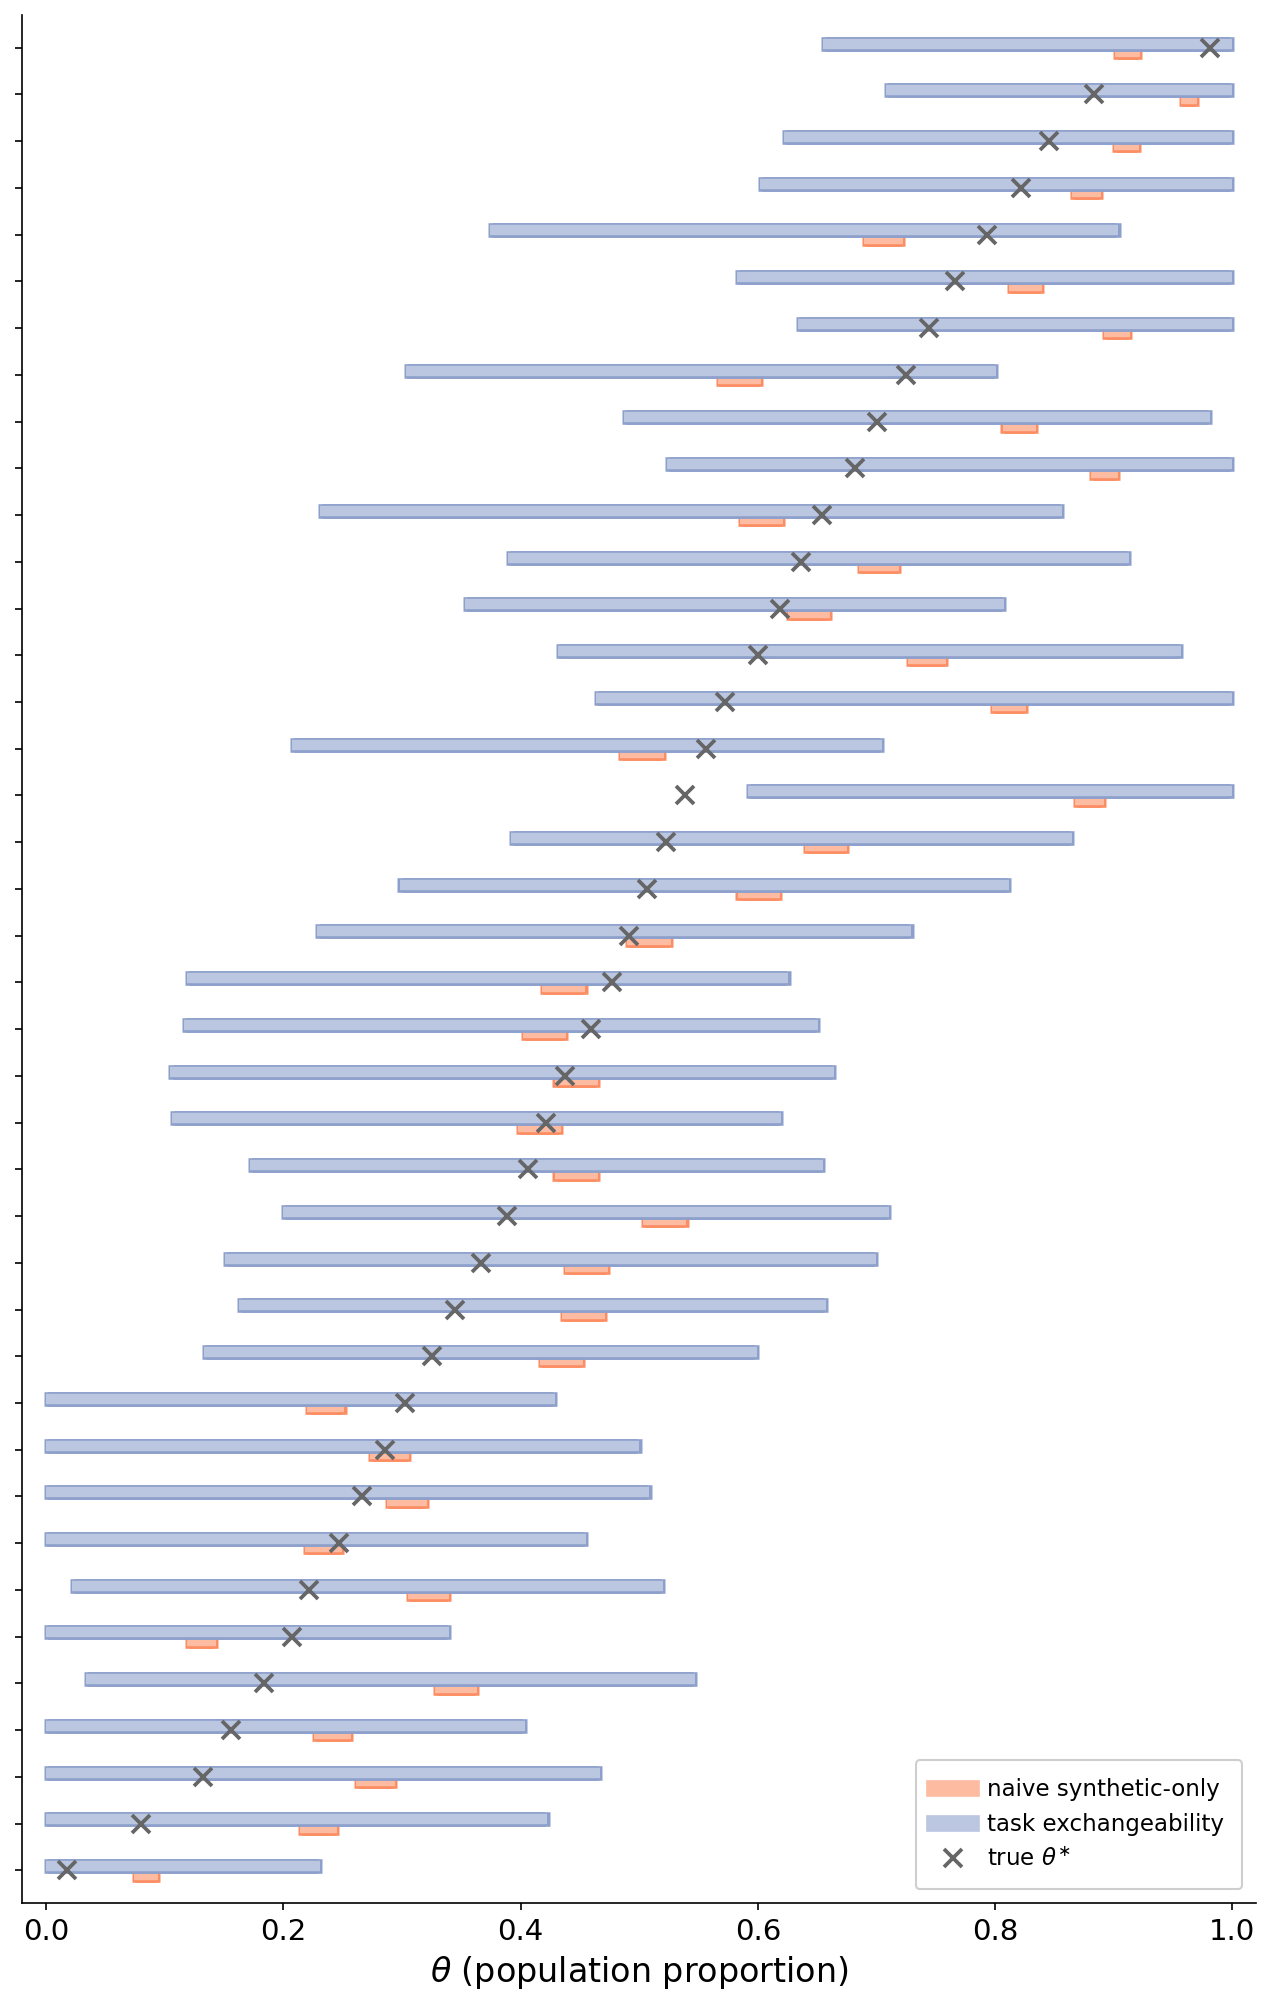

In [5]:
show(repro_simulated(100, 0.10))    # T = 100, alpha = 0.10

Each row is one Monte-Carlo replication, `×` marks the true $p$, the wide bar is
Algorithm 1 and the narrow one the naive interval. The 1000 replications are
subsampled to a readable 40 spanning the range (`select_records(..., mode="spread")`);
the coverage in the table above uses all of them.

## 3 · ANES — silicon sampling for feeling thermometers

**Estimand.** The mean American National Election Studies *feeling thermometer*
score — respondents rate a social or political group from 0 (maximally
unfavorable) to 100 (maximally favorable) — for one target group within one
partisan subgroup of the electorate.

**Task.** One (target group × respondent partisanship) pair. Eleven thermometer
targets × three partisanship levels (Democrat, Republican, Independent) = 33
tasks per wave.

**Historical tasks.** The same 33 pairs measured in an *earlier* survey wave. We
calibrate on 2016 and predict 2020 — a genuine temporal split, not leave-one-out.
$\Delta_j$ is GPT-3.5's simulation bias for pair $j$ in 2016; task
exchangeability assumes that bias is exchangeable with the 2020 bias.

**Data.** The silicon samples of Bisbee et al. (2024), generated by prompting
GPT-3.5 to adopt each respondent's demographic and political profile and return a
0–100 rating. Each respondent contributes exactly one LLM rating, so the design is
**paired** and $N_j = n_j$: the gap CI uses per-respondent differences. The 2020
target tasks have 657–1,795 respondents (median 1,596).

**Allocation.** Absolute, $(\alpha_1,\alpha_2,\alpha_3) = (0.005,\, 0.005,\, \alpha - 0.01)$
— with samples this large the first two budgets are nearly free, so almost the
whole budget goes to the conformal band.

In [6]:
rerun("ANES")               # python -m Alg.inference.run_inference --app ANES
table("ANES")

RERUN=False — reading the deposited Results/ANES/


task_def,method,alpha,n,coverage %,mean width,clipped,W1,W2,W3
main,Algorithm 1,0.100,33,100.000,35.224,34.781,1.106,4.684,29.434
main,Algorithm 1,0.150,33,96.970,30.023,29.926,1.106,4.271,24.647
main,naive synth-only,0.100,33,3.030,0.648,0.648,0.648,0.000,0.000
main,naive synth-only,0.150,33,3.030,0.567,0.567,0.567,0.000,0.000


At $\alpha = 0.15$ Algorithm 1 covers **97%** of the held-out 2020 means with a
mean width of about 30 points on the 0–100 scale. The naive synthetic-only
intervals — which treat the GPT-3.5 ratings as real survey responses — are about
0.6 points wide and cover **3%**. The simulated ratings vary far less than real
ones, so the naive interval concentrates tightly around a biased center.

The decomposition explains the 30 points: `W1` ≈ 1.1 and `W2` ≈ 4.3, but `W3` ≈
24.6. The width is almost entirely the across-task spread of GPT-3.5's bias, and
no amount of extra data would shrink it.

saved /private/tmp/release-v2/task-exchangeability-v1/Plots/ANES/forest_anes_main_alpha015.png (+ .pdf)


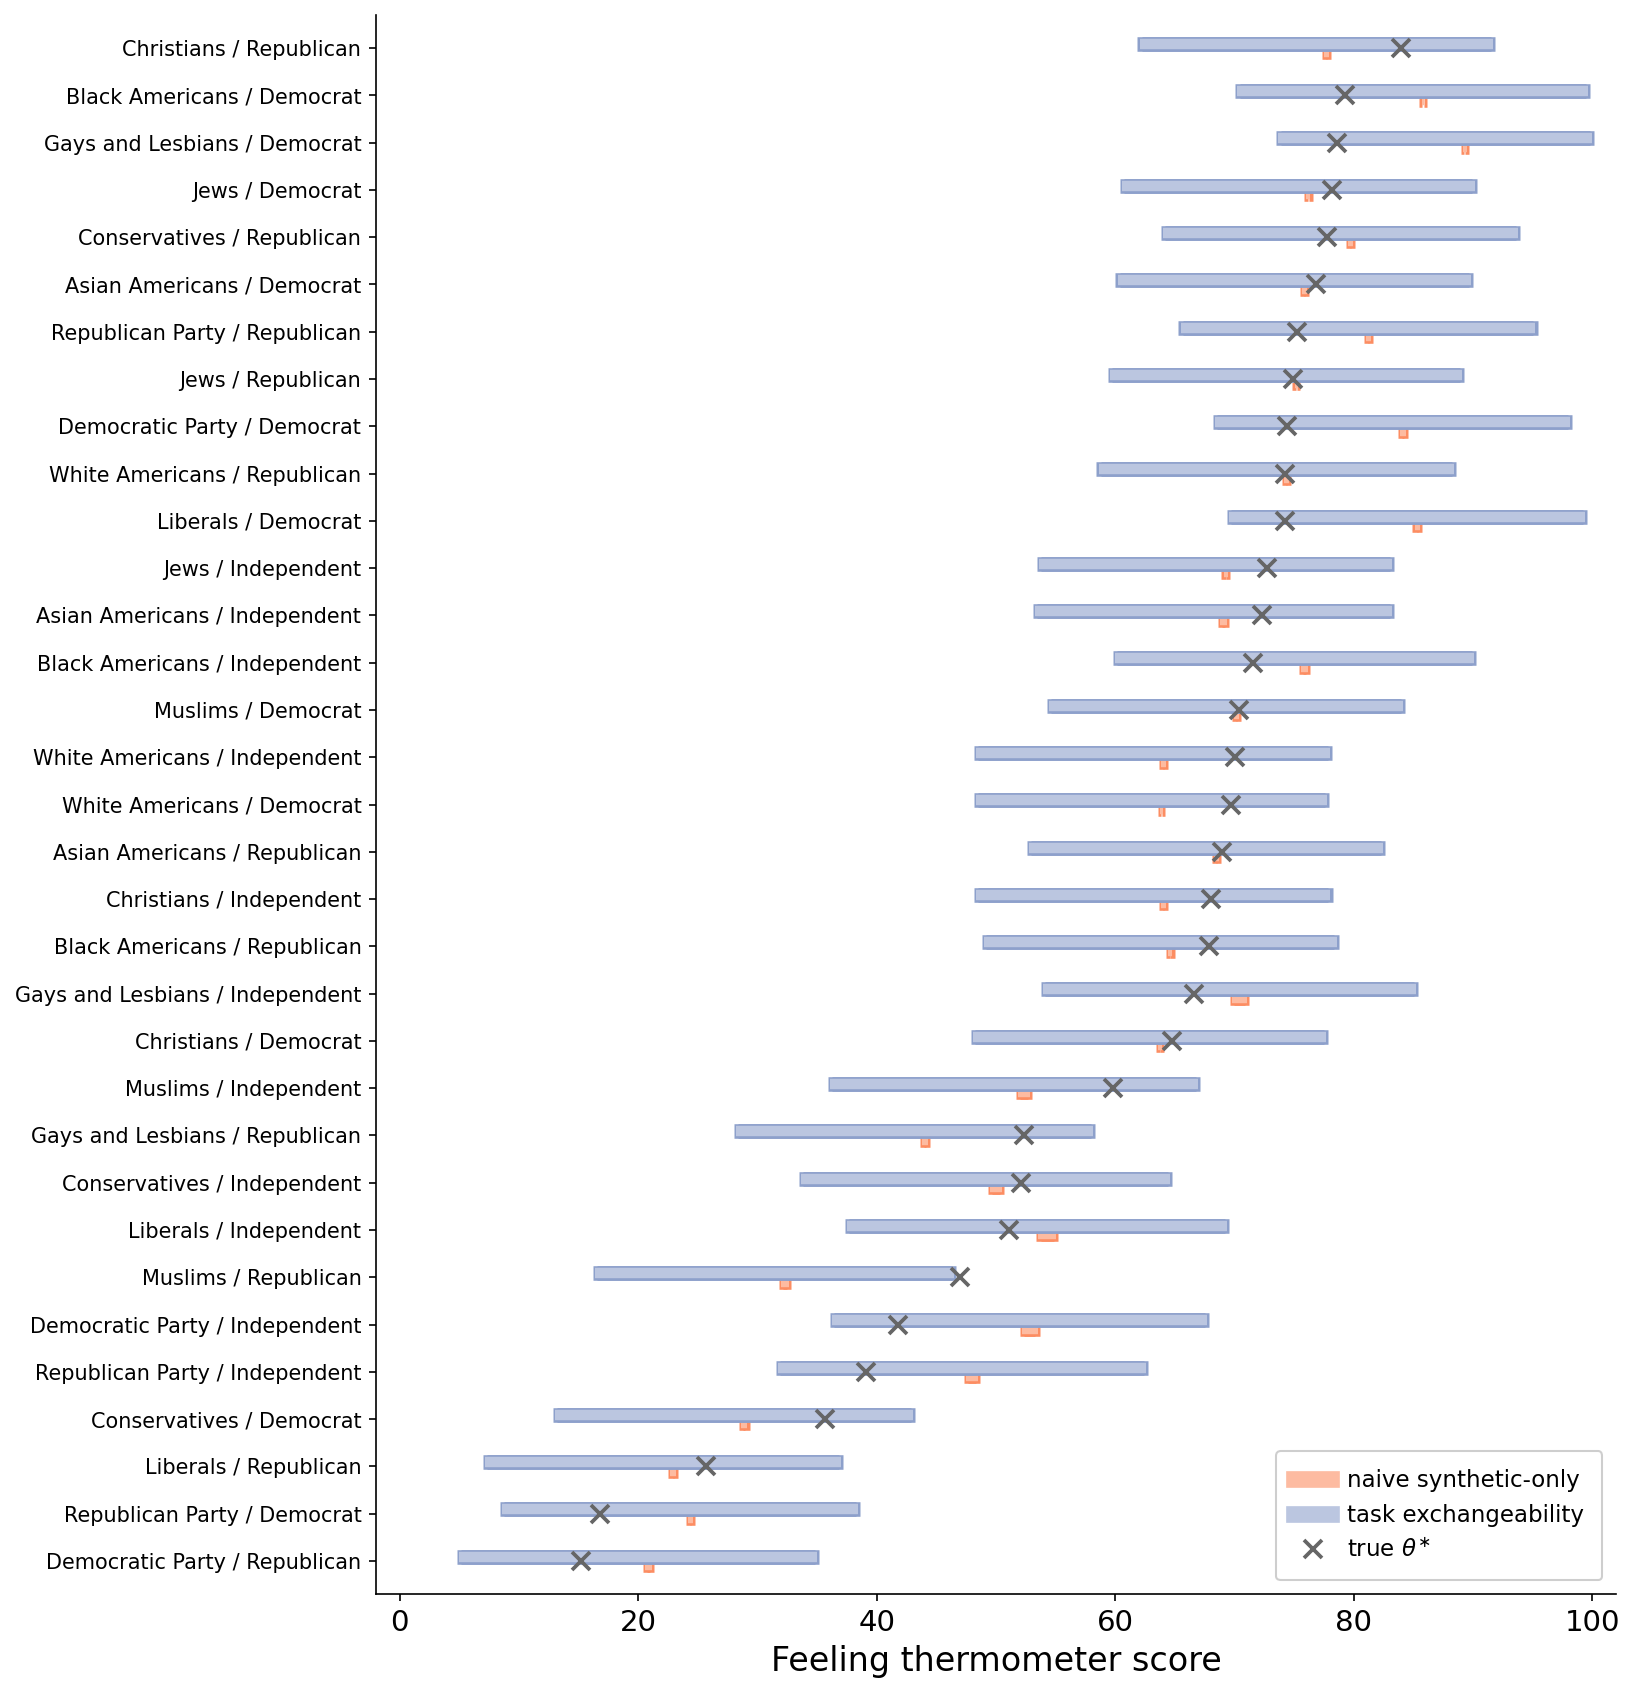

In [7]:
show(repro_anes("main", 0.15))          # paper Figure: ANES, all 33 tasks

saved /private/tmp/release-v2/task-exchangeability-v1/Plots/ANES/forest_anes_preview_alpha015.png (+ .pdf)


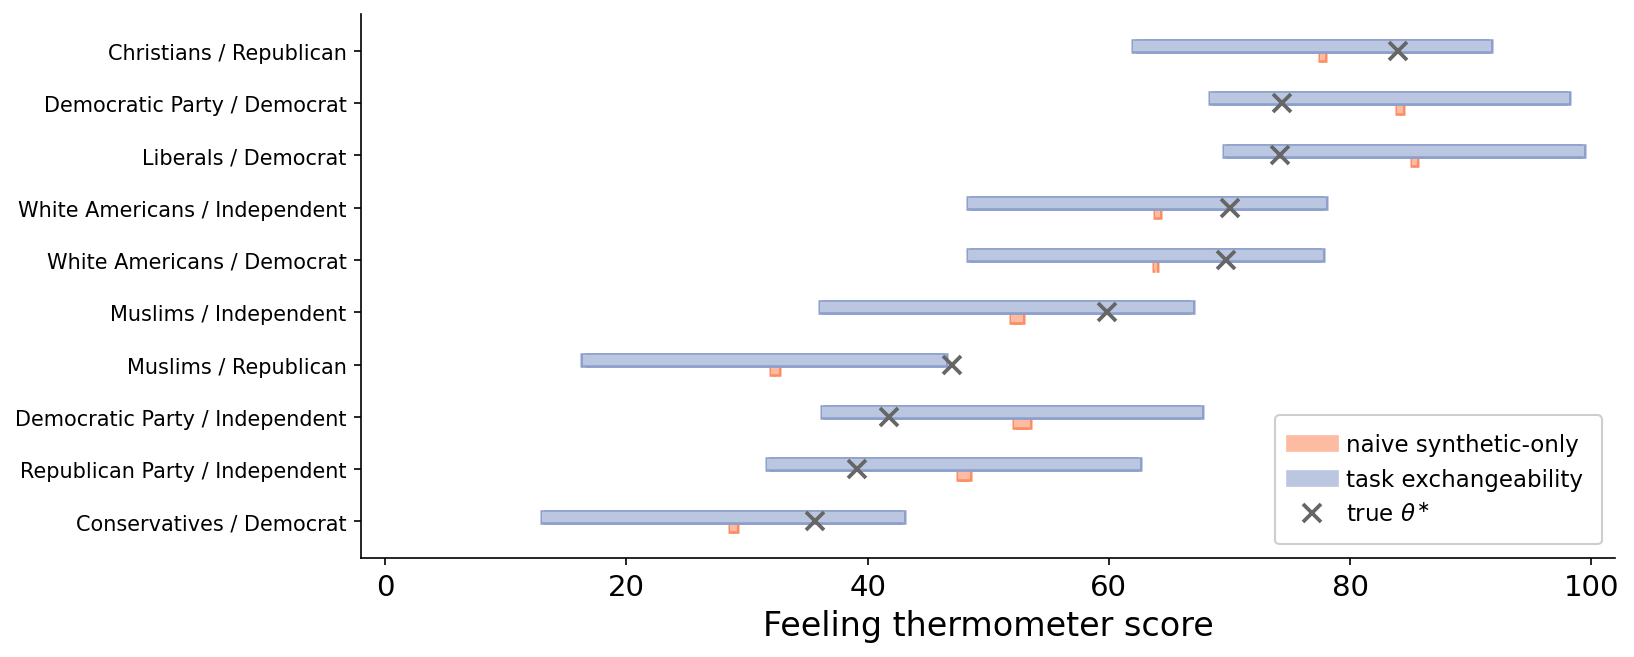

In [8]:
show(repro_anes("preview", 0.15))       # paper Figure: the 10 borderline tasks (intro)

The preview panel is not a random subset: `_borderline()` picks the ten tasks
whose true $\theta^*$ sits closest to the edge of its Algorithm-1 interval — the
hardest cases, where the calibrated band only just holds.

## 4 · Pew ATP — a two-dimensional target

**Estimand.** The survey-weighted proportion of respondents approving of the
sitting president (`POL1JB` for Biden, `POL1DT` for Trump), over 12 Pew American
Trends Panel field dates from February 2017 to October 2024.

**Why two dimensions.** Approval is sharply polarized: co-partisans approve at
70–85%, the opposing party at 5–15%, with almost nothing in between. A single
rate per region blends two nearly disjoint regimes. So the target for each
(field date × region) cell is the *pair*

$$\theta_j = \bigl(\theta_j^{\mathrm{co}},\; \theta_j^{\mathrm{opp}}\bigr),$$

and we apply Algorithm 3, the multidimensional procedure: a rectangular joint
region whose two coordinates are calibrated separately and combined by
Bonferroni, so each
coordinate is run at $\alpha/D$ with $D = 2$, then split $(0.05,\,0.10,\,0.85)$
across $\alpha_1,\alpha_2,\alpha_3$.

**Task.** One (field date × census region) cell — 12 × 4 = 48 tasks.

**Data.** Unlike ANES, the synthetic responses are generated here: every panelist's
profile (region, age, gender, education, race and ethnicity, religion, income,
party ID) is sent to GPT-4o, four independent generations per respondent are
averaged into a synthetic approval indicator, and both estimators are Hájek
(weighted) means. Roughly 66,000 respondent-level real–synthetic pairs. A second
model, Gemini 2.0 Flash, is run identically.

**Two evaluation protocols**, both in the registry:

- **LOO** (`multidim_gpt_4o`) — each of the 48 cells held out in turn, calibrated on the other 47.
- **Temporal** (`multidim_gpt_4o_temporal`) — calibrate on the 40 cells from the ten earliest field dates, forecast the 8 cells from the two most recent waves (W149, W156). This mirrors the real use case: past waves calibrate, future waves are predicted.

Which protocol a task definition uses is read from `Data/Pew/info.json`, not
hard-coded.

In [9]:
rerun("Pew")                # python -m Alg.inference.run_inference --app Pew
table("Pew", decomp=False)  # the multidim path records intervals, not the W1/W2/W3 split

RERUN=False — reading the deposited Results/Pew/


task_def,method,alpha,n,coverage %,mean width,clipped
multidim_gemini_20_flash,Algorithm 3 (multidim),0.100,64,100.000,1.000,1.000
multidim_gemini_20_flash,Algorithm 3 (multidim),0.150,64,100.000,0.391,0.391
multidim_gemini_20_flash,Algorithm 3 (multidim),0.200,64,100.000,0.386,0.386
multidim_gemini_20_flash,naive synth-only,0.100,64,7.812,0.048,0.048
multidim_gemini_20_flash,naive synth-only,0.150,64,7.812,0.044,0.044
multidim_gemini_20_flash,naive synth-only,0.200,64,6.250,0.041,0.041
multidim_gemini_20_flash_temporal,Algorithm 3 (multidim),0.200,16,100.000,0.405,0.405
multidim_gemini_20_flash_temporal,naive synth-only,0.200,16,6.250,0.038,0.037
multidim_gpt_4o,Algorithm 3 (multidim),0.100,96,100.000,0.365,0.365
multidim_gpt_4o,Algorithm 3 (multidim),0.150,96,100.000,0.357,0.357


`n` counts coordinate-rows, so it is twice the number of tasks: 96 = 48 × 2 for
GPT-4o LOO, 16 = 8 × 2 for the temporal split. Widths are pooled over the two
coordinates; the paper reports them separately (about 0.44 co-partisan, 0.20
opposition, averaging to the 0.32 shown here).

At $\alpha = 0.20$ the rectangular region covers **all 48** GPT-4o LOO tasks on
both coordinates, and all 8 forecast cells in the temporal split. The naive
rectangle covers **zero** in both: GPT-4o systematically overstates co-partisan
approval and understates opposition approval, so its narrow intervals never
contain the truth. Gemini 2.0 Flash behaves the same way, with the naive
baseline reaching 6–8% rather than 0%.

One row is degenerate and worth flagging: **Gemini LOO at $\alpha = 0.10$ has
width exactly 1.0**. With 32 tasks, $\alpha/D = 0.05$ and an $\alpha_3$ share of
0.85, the upper conformal order statistic $k_U = \lceil (T+1)(1-\alpha_3/2)\rceil$
exceeds $T$, so the band is infinite and clips to the full $[0,1]$ range. The
100% coverage in that row is real but vacuous: with this budget there are too few
historical tasks to form a finite band.

saved /private/tmp/release-v2/task-exchangeability-v1/Plots/Pew/forest_pew_gpt_4o_multidim_alpha020.png (+ .pdf)


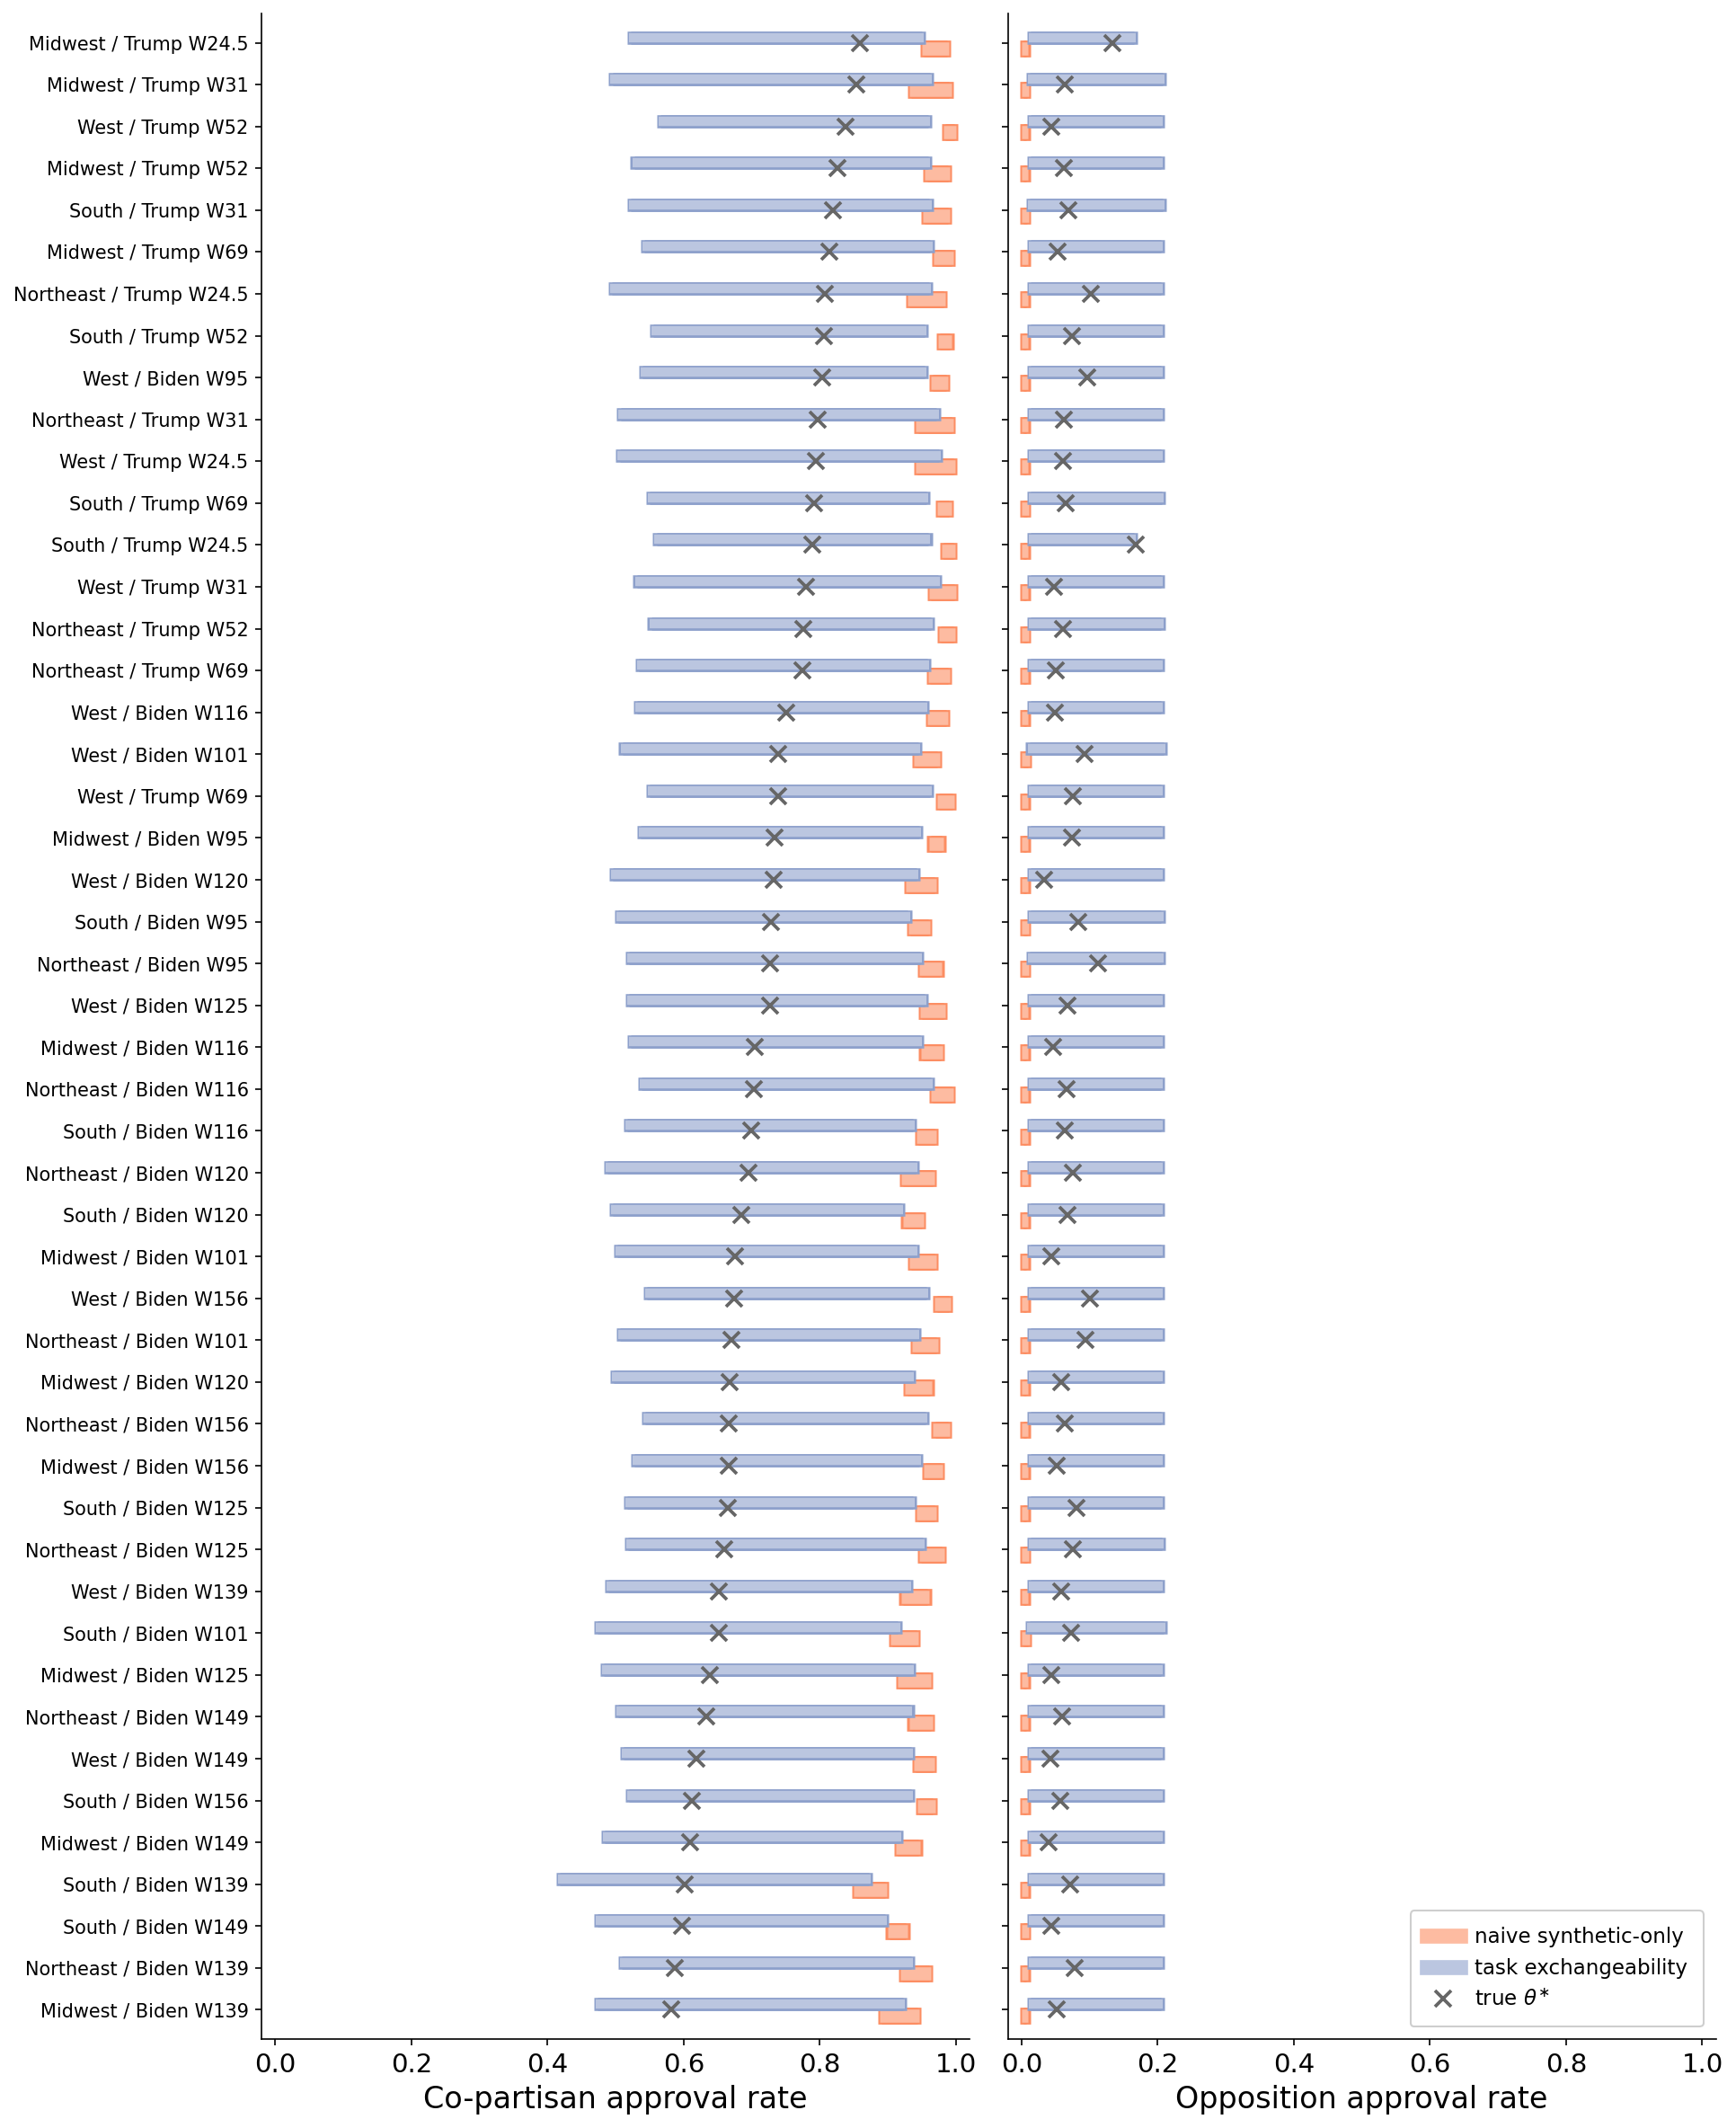

In [10]:
show(repro_pew("gpt_4.o", 0.20), width=1000)                   # paper Figure: LOO

saved /private/tmp/release-v2/task-exchangeability-v1/Plots/Pew/forest_pew_gpt_4o_multidim_temporal_alpha020.png (+ .pdf)


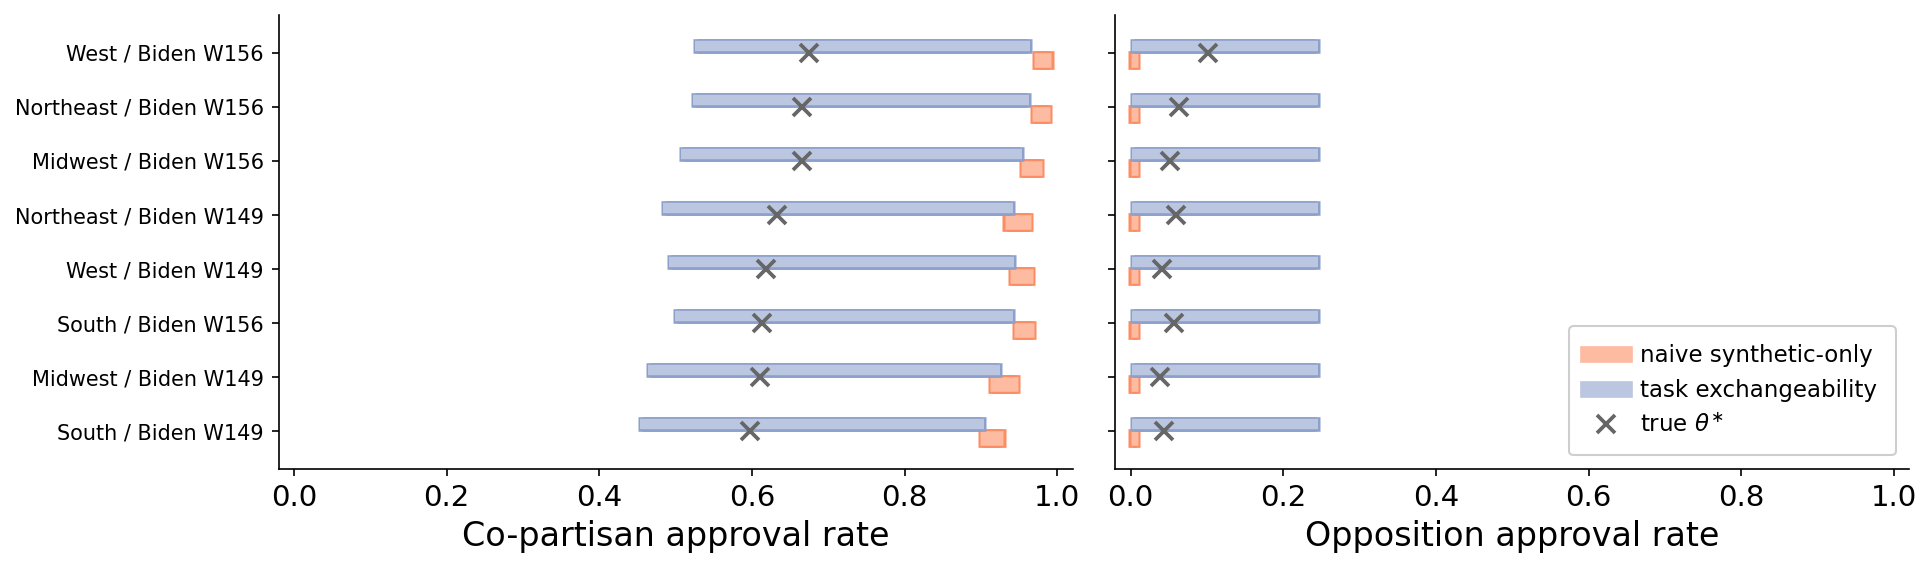

In [11]:
show(repro_pew("gpt_4.o", 0.20, temporal=True), width=1000)    # paper Figure: temporal

Left panel is the co-partisan coordinate, right the opposition one; rows are
shared and sorted by the true co-partisan rate. The polarization is the gap
between the two clusters. In the temporal figure all eight forecast cells are
covered on both coordinates while the naive intervals — centered near 0.95
co-partisan and near 0 opposition — miss every one.

## 5 · Arena win rates — evaluating AI models with an autorater

**Estimand.** For a model $m$, the probability that a *human* evaluator prefers
$m$'s response to that of a randomly drawn opponent from the reference pool, on a
randomly drawn prompt.

**The problem.** When a new model ships you want an evaluation immediately, but
human preference votes arrive slowly. An autorater — here a reward model trained
by Arena — can vote instantly, at the cost of bias relative to human judgment.

**Task.** One model. $\theta_j$ is model $j$'s human win rate, $\tilde\theta_j$ its
autorater win rate, and $\Delta_j$ the autorater's evaluation bias for that model.
73 models, evaluated leave-one-out: each is the target in turn, the other 72 are
the historical tasks.

**Data.** Prompts, human votes and autorater votes from Arena. The design is
**paired** — every prompt yields both a human and an autorater vote on the same
pair of responses, so $N_j = n_j$. Median 7,918 votes per model (range
2,865–20,324), roughly 555,000 human–autorater comparison pairs.

**Two targets.** This is where the population and finite-sample targets are
compared directly:

- **Algorithm 1** targets the population win rate $\theta^*(\mathcal{P}^*)$: full three-budget construction.
- **Algorithm 4** targets the finite-sample $\theta^*(S)$. The synthetic estimate is *observed exactly*, so there is no $\alpha_1$ CI, and the observed gaps $\hat\Delta_j$ need no per-task interval — the entire budget goes to a single conformal step. Theorem 4 makes this tightly calibrated, coverage in $[1-\alpha,\, 1-\alpha + \tfrac{2}{T+1})$.

These intervals come from the application-specific code in
`provenance/autorater_winrate/` and are ingested into the common schema by
`Alg/result_process/ingest_results.py`, so they flow through the same
Results → plots/tables stages as everything else.

In [12]:
rerun("Autorater")          # python -m Alg.inference.run_inference --app Autorater
table("Autorater", decomp=False)   # ingested intervals carry no W1/W2/W3 split

RERUN=False — reading the deposited Results/Autorater/


task_def,method,alpha,n,coverage %,mean width,clipped
AR_M,Algorithm 1,0.100,73,100.000,0.067,0.067
AR_M,Algorithm 1,0.150,73,100.000,0.063,0.063
AR_M,Algorithm 1,0.200,73,100.000,0.056,0.056
AR_M,Algorithm 4 (finite-sample),0.100,73,91.781,0.032,0.032
AR_M,Algorithm 4 (finite-sample),0.150,73,87.671,0.028,0.028
AR_M,Algorithm 4 (finite-sample),0.200,73,82.192,0.024,0.024
AR_M,naive synth-only,0.100,73,19.178,0.006,0.006
AR_M,naive synth-only,0.150,73,15.068,0.005,0.005
AR_M,naive synth-only,0.200,73,12.329,0.005,0.005


At $\alpha = 0.10$: Algorithm 1 covers **all 73** models with mean width 0.067,
Algorithm 4 covers **91.8%** at width 0.032, and the naive intervals cover
**19%** at width 0.006.

The 91.8% is the point of the comparison. Theorem 4 guarantees coverage in
$[1-\alpha,\, 1-\alpha+\tfrac{2}{T+1}) = [0.900,\, 0.927)$ with $T = 73$, and
91.8% lands inside that band: valid, and not conservative by more than about 2.7
points. Section 2 showed the same two-sided behaviour on simulated data where
coverage can be computed exactly; here it holds on real Arena votes.

Algorithm 1 covers everything at more than twice the width. That is the price of
the stronger population target.

saved /private/tmp/release-v2/task-exchangeability-v1/Plots/Autorater/forest_autorater_naive_vs_alg1_alpha010.png (+ .pdf)


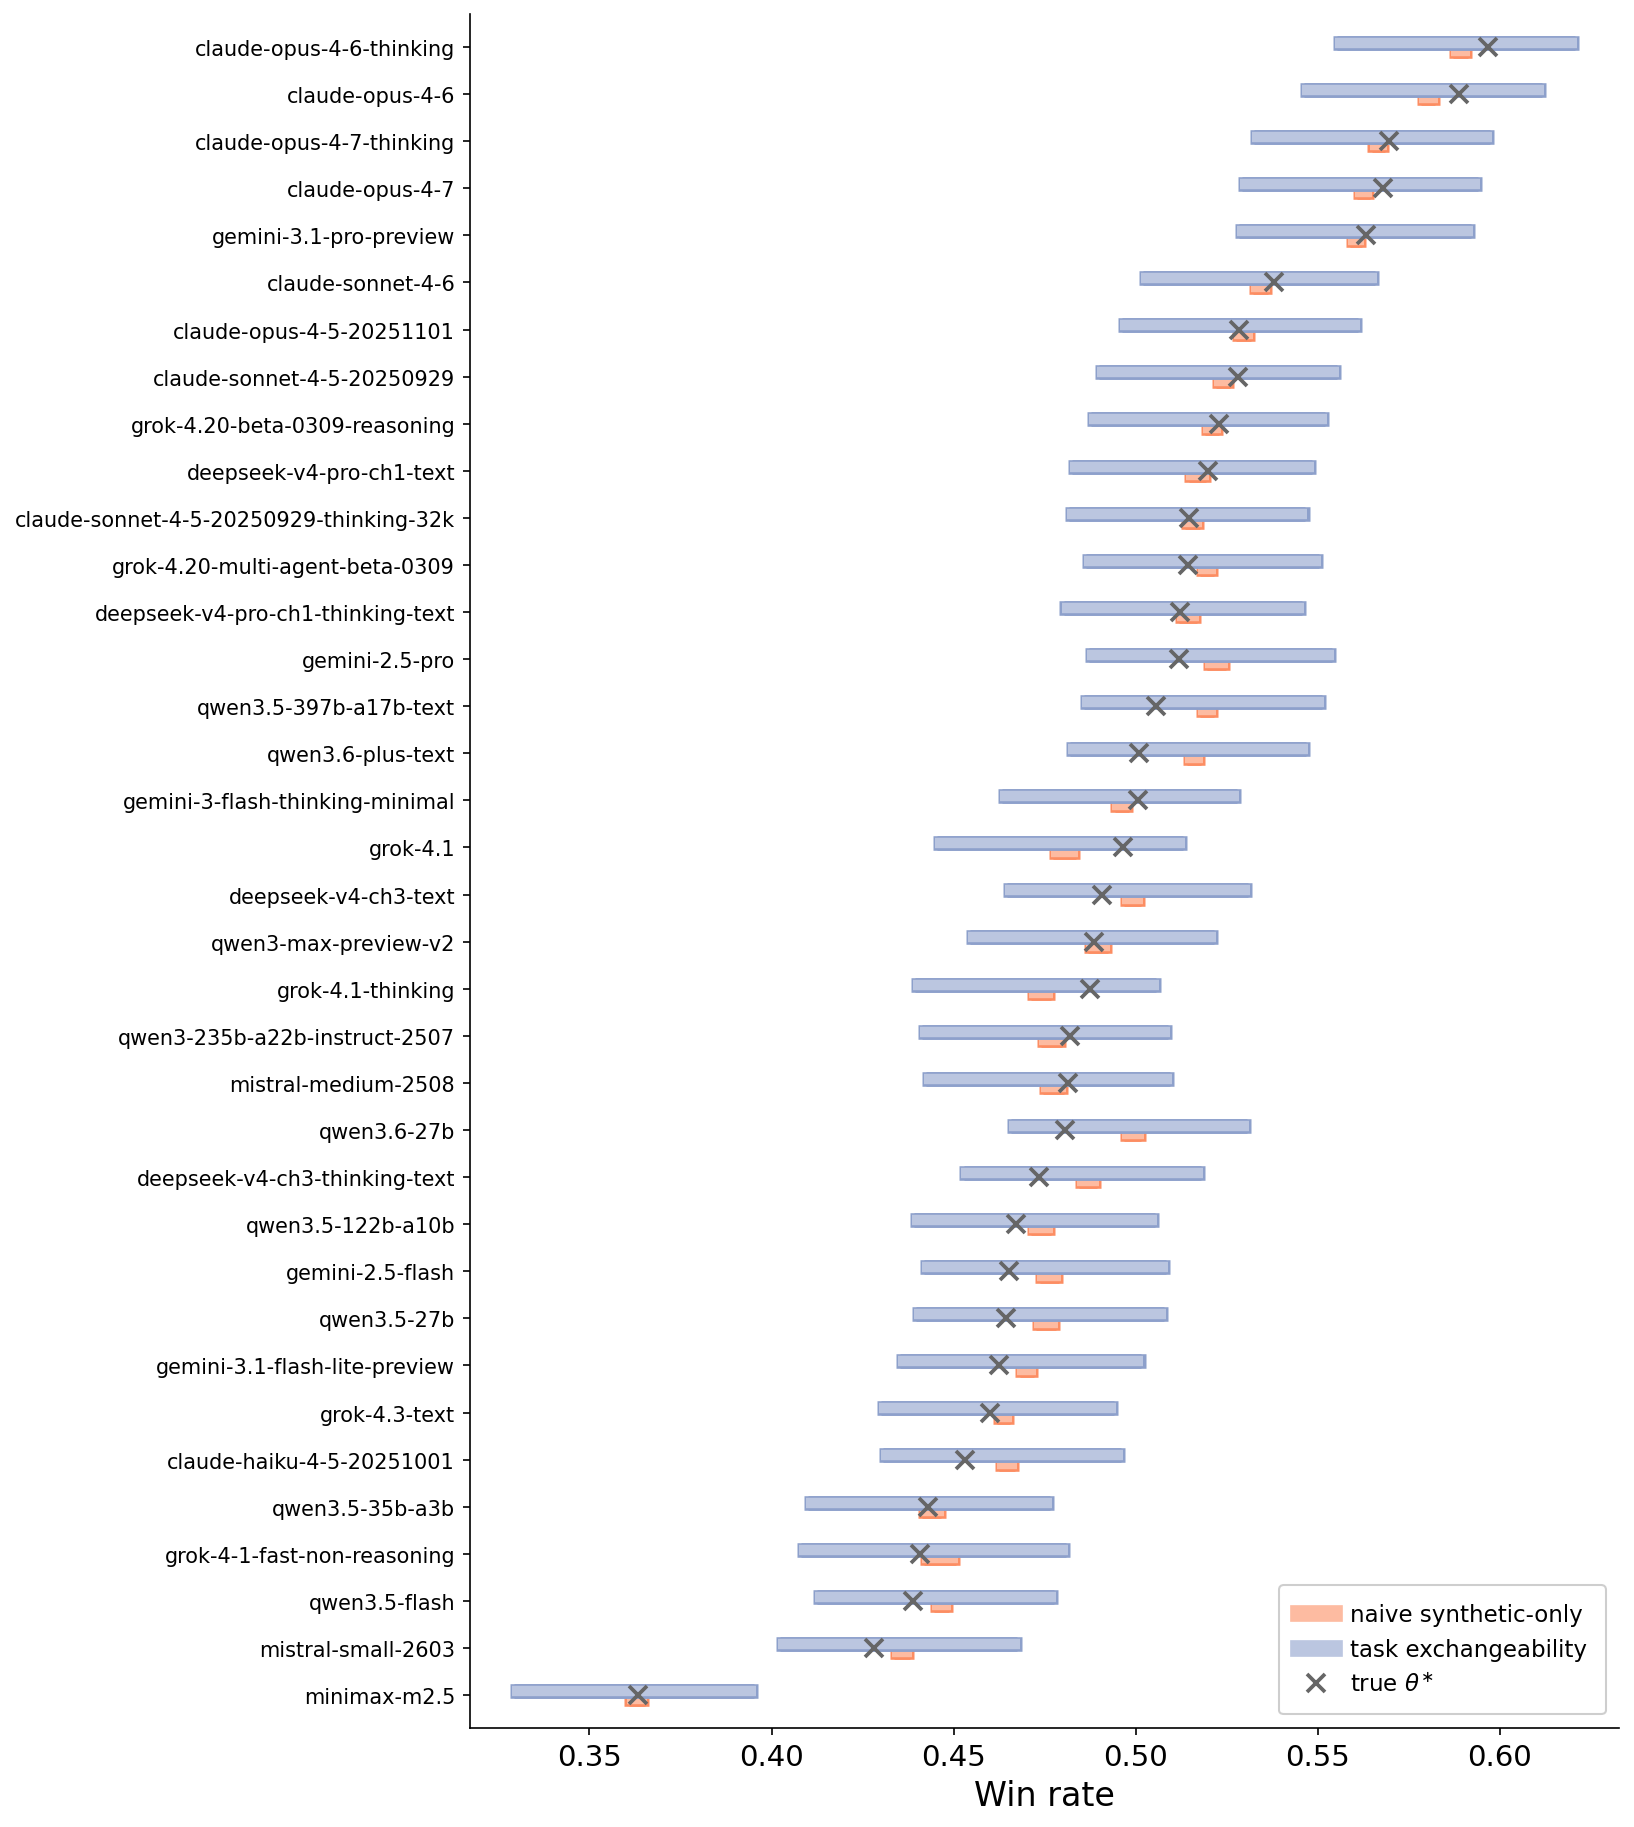

In [13]:
show(repro_autorater("naive_vs_alg1", 0.10), width=950)      # paper Figure: Alg 1 vs naive

saved /private/tmp/release-v2/task-exchangeability-v1/Plots/Autorater/forest_autorater_alg1_vs_onepiece_alpha010.png (+ .pdf)


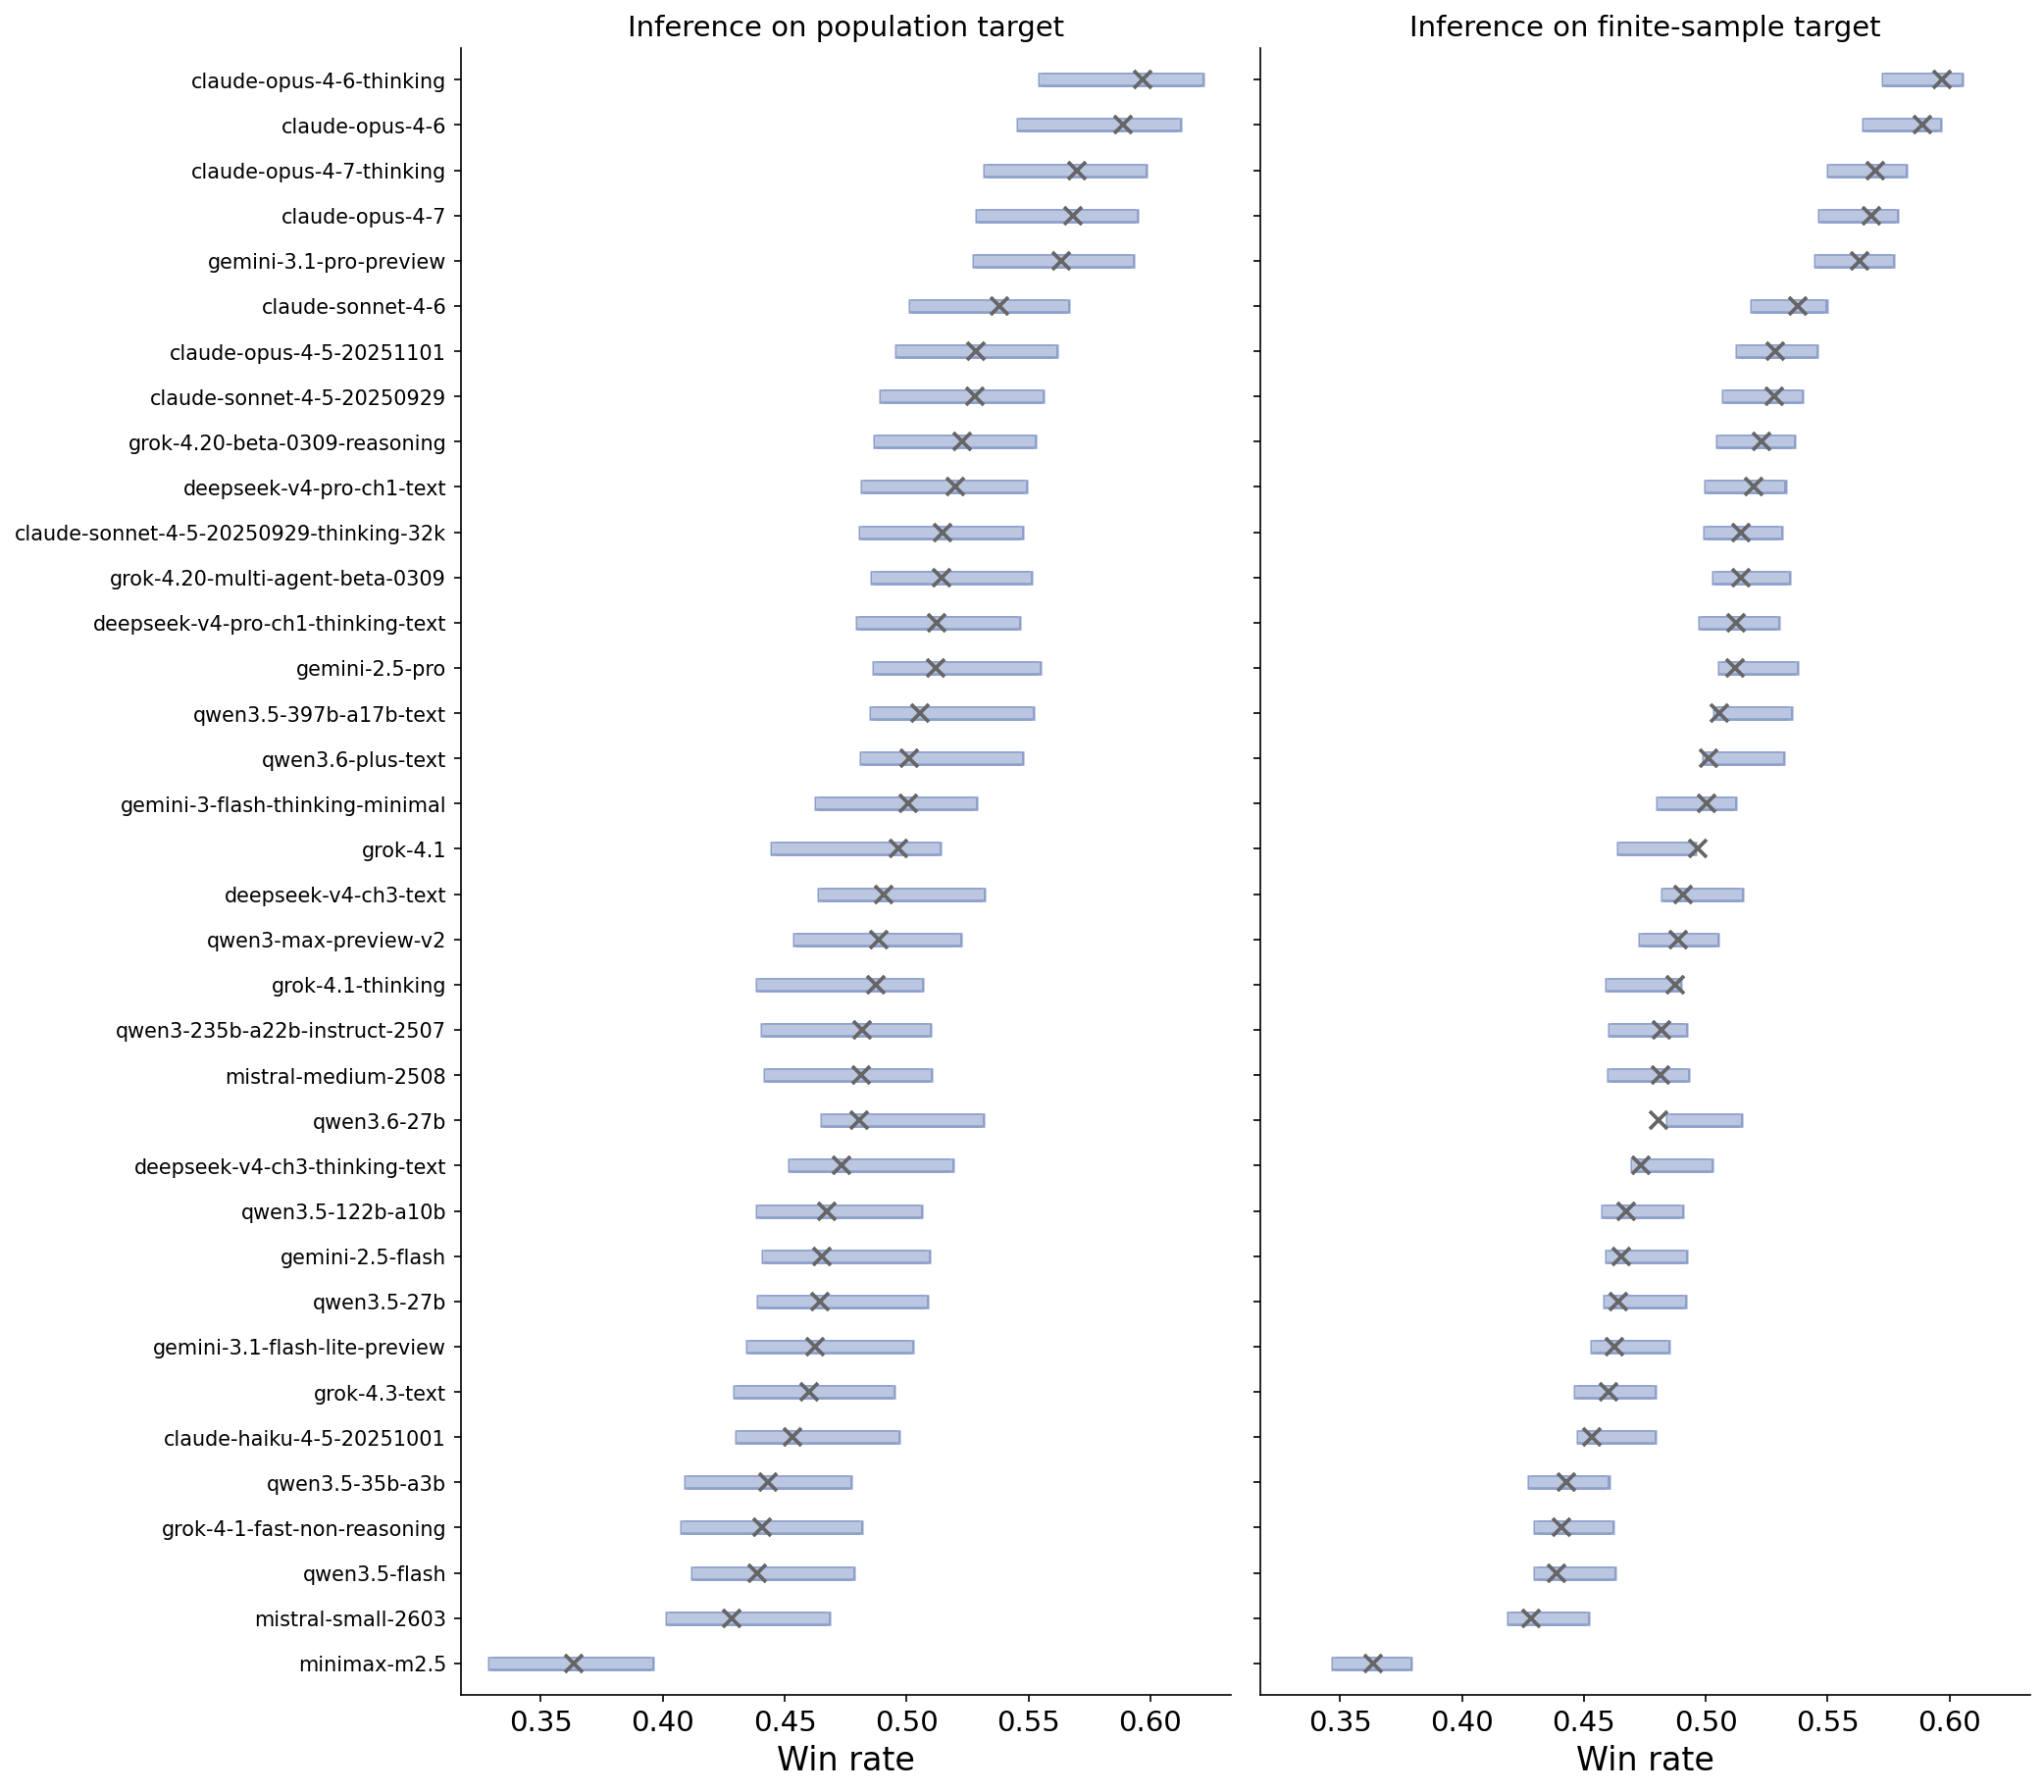

In [14]:
show(repro_autorater("alg1_vs_onepiece", 0.10), width=1100)  # paper Figure: population vs finite-sample

In the two-panel figure the `×` marks the finite-sample target in *both* panels —
the population target cannot be computed from real data, so it is not plottable
even though the left panel is the procedure that targets it.

Rows are restricted to a fixed list of public model families
(`_AUTORATER_FAMILIES` in `plot_forest.py`); models under pre-release testing on
Arena at collection time are pseudonymized in the deposit and do not appear.

## 6 · Arena Bradley–Terry scores

**Estimand.** A model's Bradley–Terry log-strength $\beta_M$ — the latent skill
parameter behind the win rates, and what a leaderboard actually ranks on. BT
scores are identified only up to an additive shift, fixed here by pinning the
reference model at $\beta = 0$.

**Task: full-field insertion.** For a held-out model $M$, pretend every battle
*not* involving $M$ is already known from human votes, fit the joint BT frame on
that universe, then place $M$ against the fixed field using only $M$'s own
battles. The truth $\theta^*_M$ is the placement from $M$'s *human* battles; the
synthetic $\tilde\theta_M$ is the same placement from $M$'s *autorater* battles.
The frame excludes $M$ entirely, so $M$'s true battles never enter calibration.

**Historical tasks.** Inside the same universe, every other later-released model
$j$ is placed against the rest of the field the same way, once from human and once
from autorater battles. Because every task inserts one model into the field
identically, the tasks are exchangeable and Algorithm 1 applies directly. Gap
standard errors come from a paired bootstrap over each model's battles — this is
what makes a full re-run slow.

**Anchor sweep.** The $m$ earliest-released models are held back as a permanent
background cohort; the remaining models are the tasks. Three anchor sizes are run
as a robustness check: `BT_m24` (50 tasks), `BT_m34` (40 tasks), `BT_m44` (30
tasks). Only *which models are eligible as tasks* changes; the frame is always the
whole field.

**Rank intervals.** Each BT interval $[L_M, U_M]$ is converted to a rank interval
against the field's point scores: best rank $1 + \#\{k : \beta_k > U_M\}$, worst
$1 + \#\{k : \beta_k > L_M\}$. These are annotated to the right of each row as
`true / TE-rank / naive`.

The figures below use `BT_m44`, the anchor size the paper's figure uses.
`Alg/data_ingestion/figure_models.py` pins the same task definition when it works
out which Arena models are safe to pseudonymize, so plotting `BT_m44` here keeps
the notebook and that disclosure calculation in agreement. Rows for models still
under pre-release testing at collection time show a `model-NN` pseudonym.

In [15]:
rerun("Autorater_BT")       # python -m Alg.inference.run_inference --app Autorater_BT
table("Autorater_BT")

RERUN=False — reading the deposited Results/Autorater_BT/


task_def,method,alpha,n,coverage %,mean width,clipped,W1,W2,W3
BT_m24,Algorithm 1,0.100,50,100.000,0.361,0.361,0.122,0.089,0.150
BT_m24,Algorithm 1,0.150,50,100.000,0.337,0.337,0.115,0.090,0.132
BT_m24,Algorithm 1,0.200,50,100.000,0.308,0.308,0.110,0.077,0.122
BT_m24,Algorithm 4 (finite-sample),0.100,50,92.000,0.132,0.132,0.000,0.000,0.132
BT_m24,Algorithm 4 (finite-sample),0.150,50,88.000,0.122,0.122,0.000,0.000,0.122
BT_m24,Algorithm 4 (finite-sample),0.200,50,80.000,0.101,0.101,0.000,0.000,0.101
BT_m24,naive synth-only,0.100,50,76.000,0.078,0.078,0.078,0.000,0.000
BT_m24,naive synth-only,0.150,50,64.000,0.068,0.068,0.068,0.000,0.000
BT_m24,naive synth-only,0.200,50,60.000,0.060,0.060,0.060,0.000,0.000
BT_m34,Algorithm 1,0.100,40,100.000,0.364,0.364,0.122,0.091,0.150


The conclusion does not move across the three anchor sizes. Algorithm 1 covers
100% at every $m$ and every $\alpha$, with mean width essentially constant
(0.361 / 0.364 / 0.365 at $\alpha=0.10$) even though the number of tasks changes
from 50 to 40 to 30. Algorithm 4 lands at or just above $1-\alpha$ throughout —
several rows hit it exactly — at roughly a third of the width. Widths are on the
$\beta$ (log-strength) scale.

The naive baseline fails more quietly here than elsewhere — 73–76% coverage at
$\alpha = 0.10$, against the near-zero of ANES and Pew — but it still undercovers
by 14 to 21 points at every level, and its intervals are the narrowest in the
table.

Algorithm 4's decomposition is `W1 = W2 = 0`, `W3 = width` — the whole budget on
one conformal step, written out.

saved /private/tmp/release-v2/task-exchangeability-v1/Plots/Autorater_BT/forest_autorater_bt_BT_m44_alg1_alpha010.png (+ .pdf)


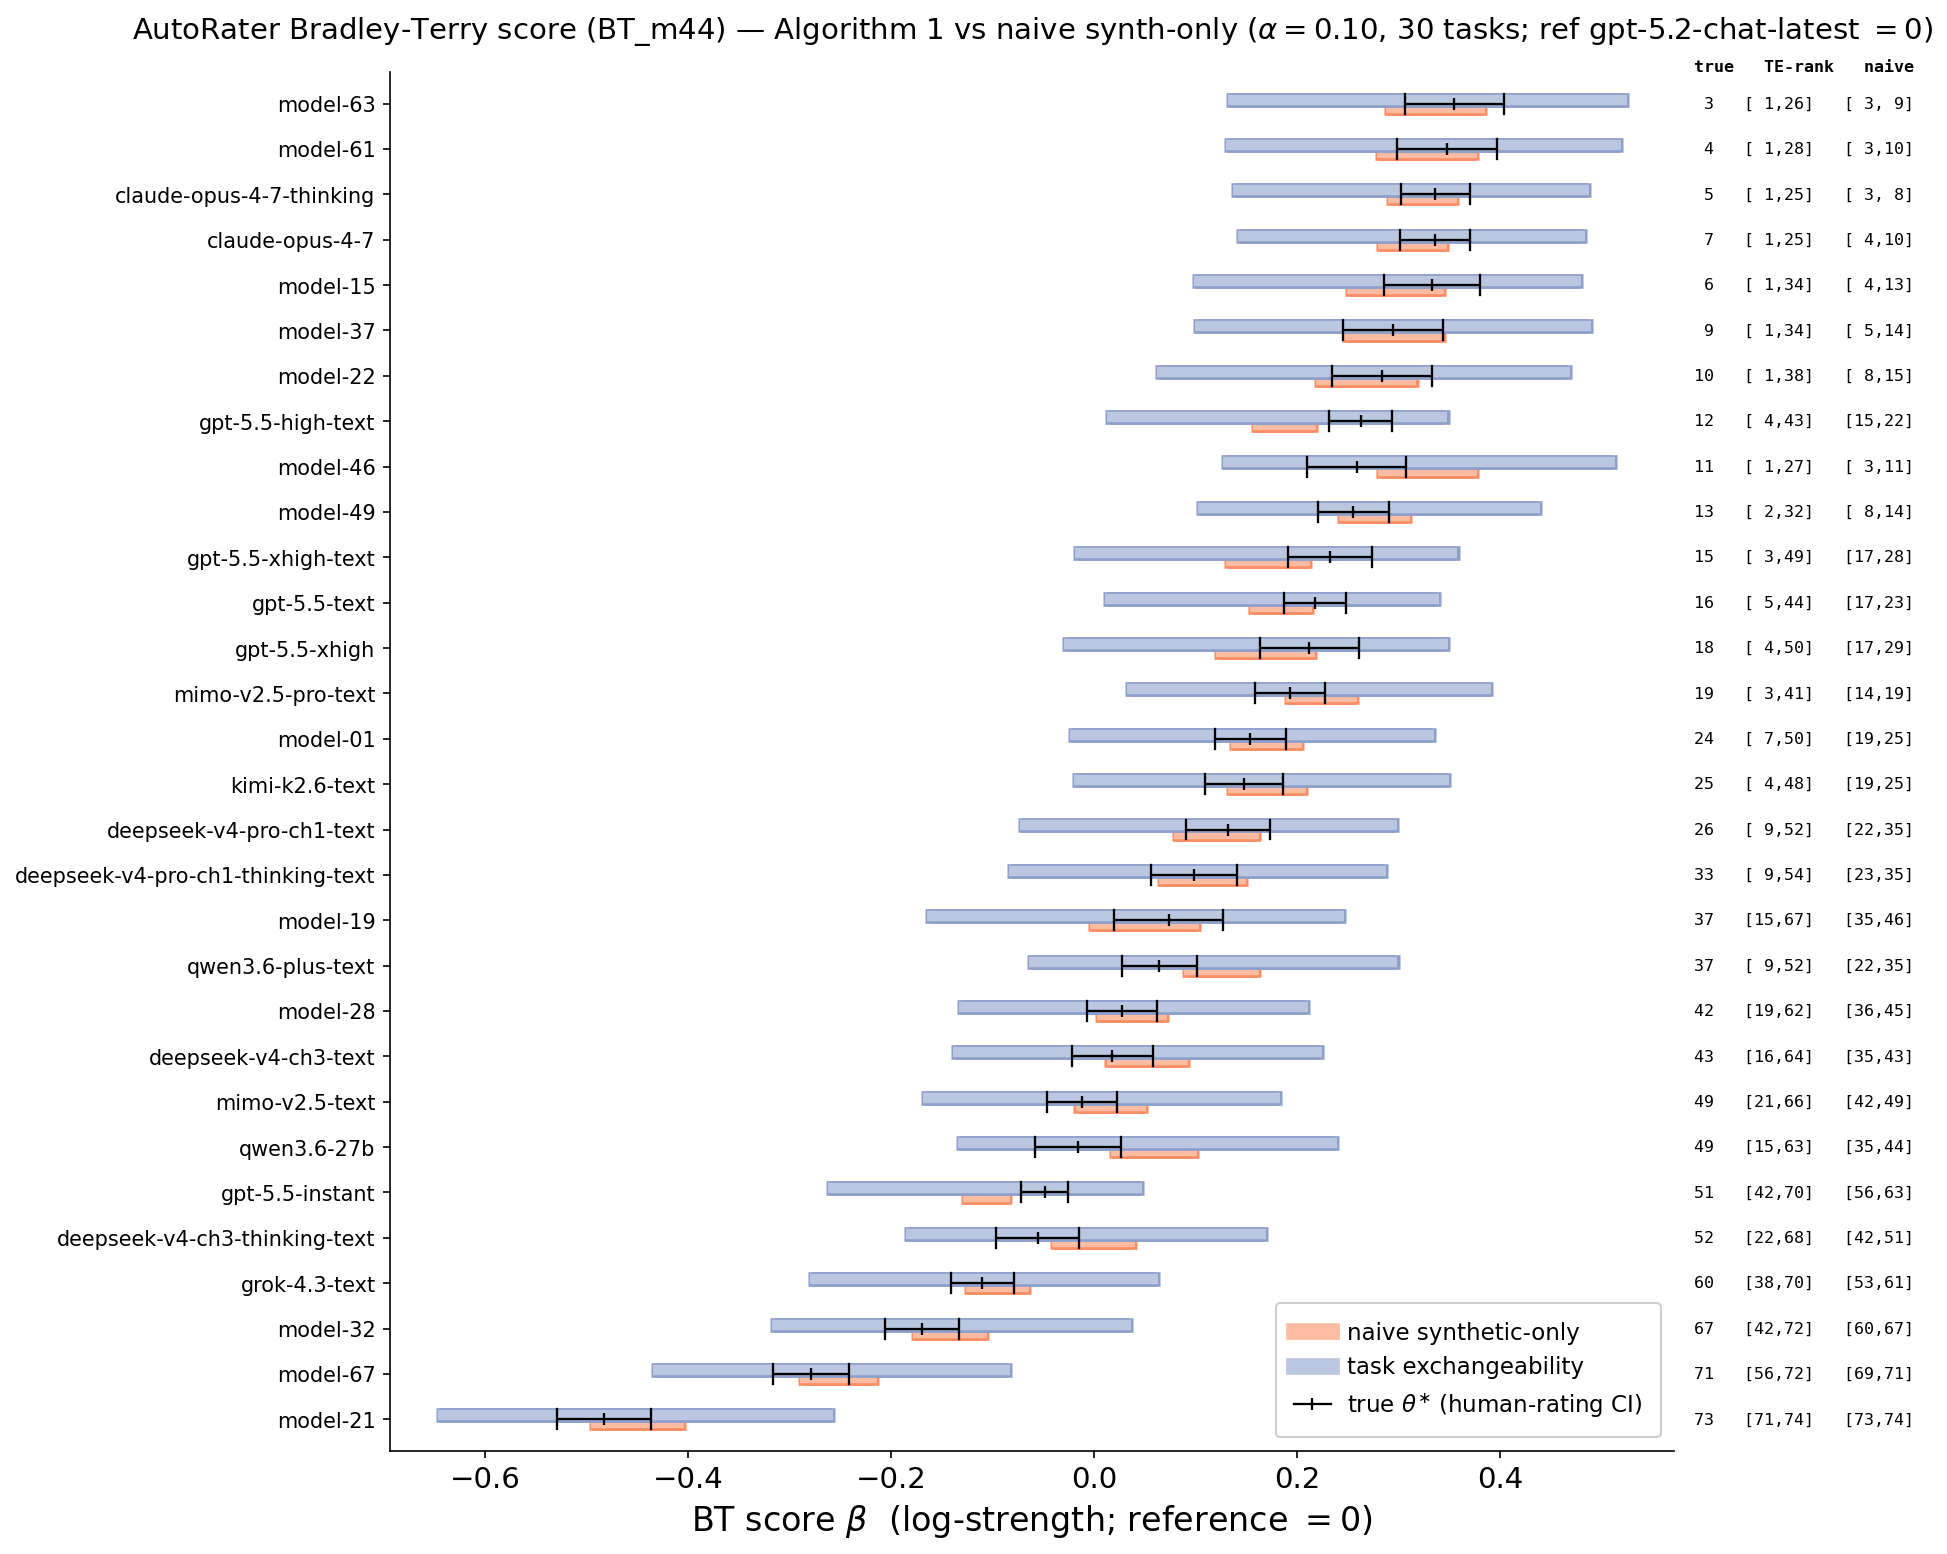

In [16]:
show(repro_autorater_bt("BT_m44", 0.10, "alg1"), width=1050)   # Algorithm 1, population target

saved /private/tmp/release-v2/task-exchangeability-v1/Plots/Autorater_BT/forest_autorater_bt_BT_m44_alg4_alpha010.png (+ .pdf)


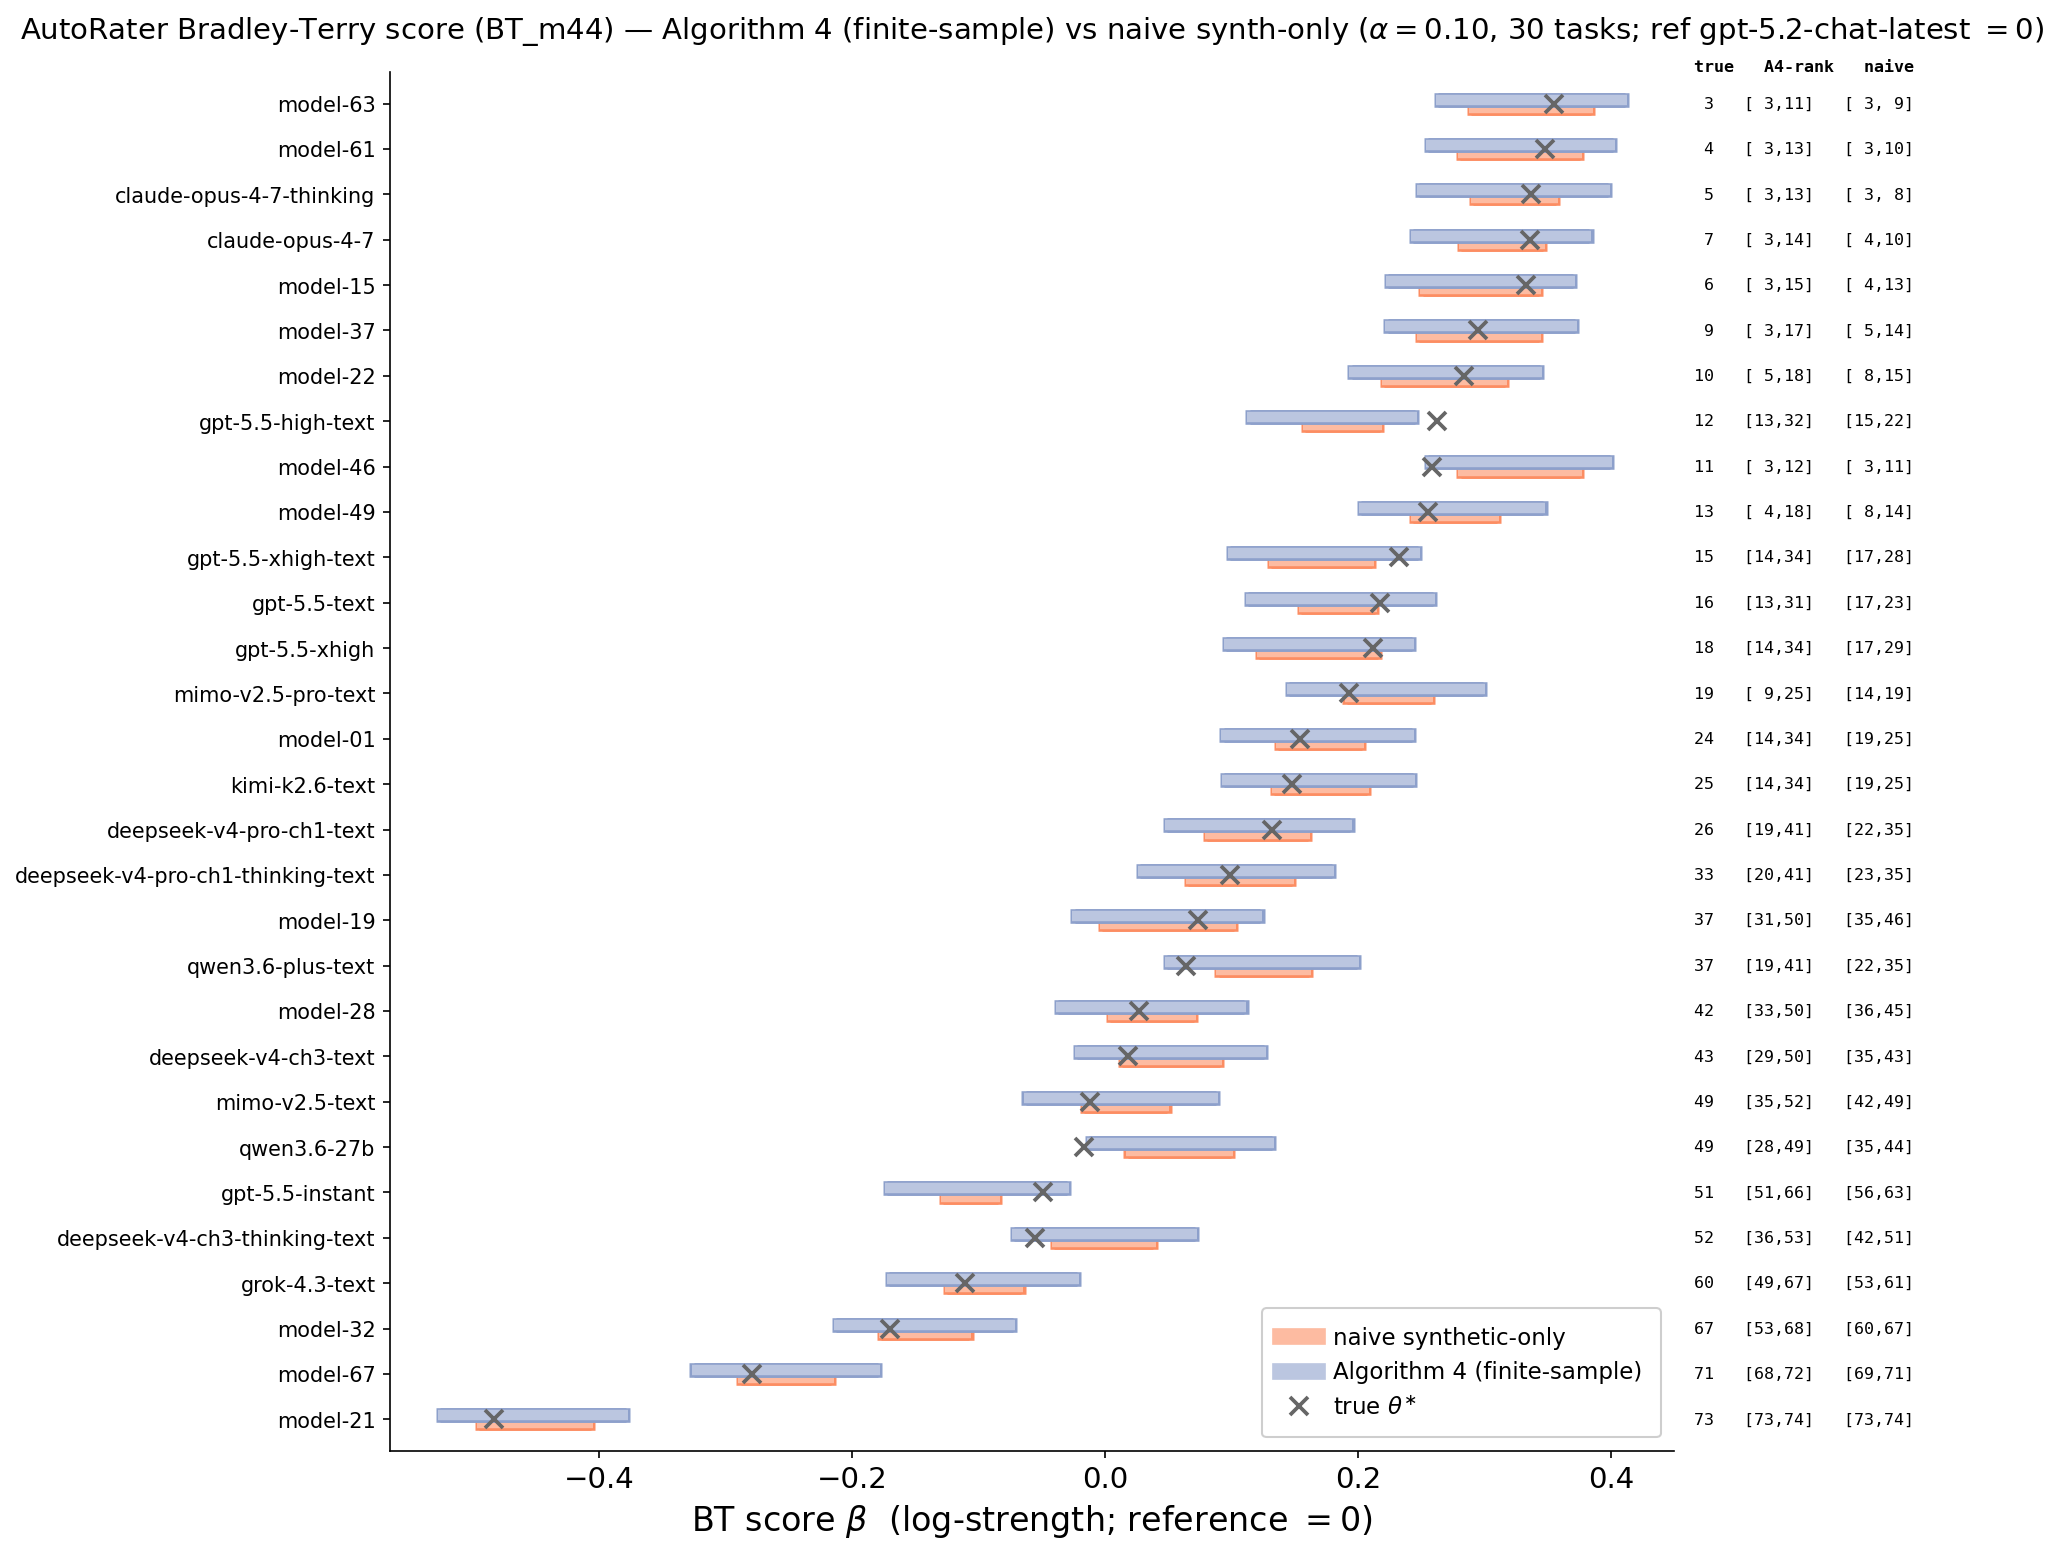

In [17]:
show(repro_autorater_bt("BT_m44", 0.10, "alg4"), width=1050)   # Algorithm 4, finite-sample target

In the Algorithm 1 panel the truth is drawn as a black *bar*, not a cross: for the
population target $\theta^*$ is itself estimated from the held-out model's human
battles, so it carries its own CI.

## 7 · All results in one table

Every row of `Results/summary_tables.csv` — the same object
`python -m Alg.result_process.summarize_tables` writes, alongside a readable
grouped version in `Results/SUMMARY.md`.

In [18]:
allrows = pd.DataFrame(summarize())
print(f"{len(allrows)} rows across {allrows.app.nunique()} applications "
      f"(same content as Results/summary_tables.csv)")
allrows.round(4)

78 rows across 5 applications (same content as Results/summary_tables.csv)


,app,task_def,alloc,algo,alpha,n_tasks,coverage_pct,mean_width,mean_width_clip,W1,W2,W3
0,ANES,main,abs_005_005,alg1,0.10,33,100.0000,35.2235,34.7812,1.1056,4.6840,29.4340
1,ANES,main,abs_005_005,alg1,0.15,33,96.9697,30.0230,29.9259,1.1056,4.2709,24.6466
2,ANES,main,abs_005_005,synth_only,0.10,33,3.0303,0.6478,0.6478,0.6478,0.0000,0.0000
3,ANES,main,abs_005_005,synth_only,0.15,33,3.0303,0.5670,0.5670,0.5670,0.0000,0.0000
4,Autorater,AR_M,prop_127,alg1,0.10,73,100.0000,0.0669,0.0669,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
73,simulated,T40,abs_005_005,alg2,0.15,1000,99.1000,0.5323,0.4911,0.0531,0.1334,0.3458
74,simulated,T40,abs_005_005,alg3,0.10,1000,90.5000,0.3458,0.3292,0.0000,0.0000,0.3458
75,simulated,T40,abs_005_005,alg3,0.15,1000,85.9000,0.2997,0.2876,0.0000,0.0000,0.2997
76,simulated,T40,abs_005_005,synth_only,0.10,1000,12.7000,0.0311,0.0311,0.0311,0.0000,0.0000


### Reproducing this outside the notebook

```bash
pip install -r requirements.txt
./reproduce.sh --check     # rebuild everything and verify it matches the deposit
```

`--check` regenerates `Results/` from `Data/` and fails if any coverage, width or
task count differs from the deposited copy. The three stages `reproduce.sh` runs,
in order:

| stage | command | reads | writes |
|---|---|---|---|
| 1 · inference | `python -m Alg.inference.run_inference` | `Data/` | `Results/` |
| 2 · figures | `python -m Alg.result_process.plot_forest --repro` | `Results/` | `Plots/` |
| 3 · tables | `python -m Alg.result_process.summarize_tables` | `Results/` | `Results/summary_tables.csv`, `Results/SUMMARY.md` |

Inference runs once and is persisted, so regenerating a figure or table never
re-runs it — which is exactly what this notebook relies on. Every `--app` flag
accepts the application names used above.

### Where to look in the code

| you want | file |
|---|---|
| Algorithms 1 and 2, and the width decomposition | `Alg/inference/core.py` |
| Algorithm 4 and the per-application drivers | `Alg/inference/methods.py` |
| Bradley–Terry field insertion | `Alg/inference/bt_autorater.py` |
| the multidimensional Pew path | `Alg/inference/_pew/multidim.py` |
| CLT / paired / bootstrap interval primitives | `Alg/inference/ci_methods.py` |
| which (app, task def, algorithm, allocation, α) combinations run | `Alg/inference/registry.py` |
| raw data → the common `TaskSet` format | `Alg/data_ingestion/loaders.py` |
| the figures in this notebook | `Alg/result_process/plot_forest.py` |

Adding an application is a data edit in `registry.py` plus a loader; the three
drivers iterate the registry and need no changes.